In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import h5py
import pickle
import joblib
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"Dataset loaded: {df.shape}")
    return df

def prepare_refugee_features(df, target_col='Refugees'):
    """
    Prepare features specifically for refugee prediction
    """
    df_processed = df.copy()

    print("\nPREPARING FEATURES FOR REFUGEE PREDICTION...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # Store country mapping
    country_mapping = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
    print(f"   Country mapping: {country_mapping}")

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Refugees',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Conflict_Intensity'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP', 'Refugees', 'Asylum Seekers']:
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

    # 6. Create interaction features
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
            df_processed['Conflict_Squared'] = df_processed['Conflict_Intensity'] ** 2
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Create refugee-to-population ratio
    if 'Refugees' in df_processed.columns and 'Population' in df_processed.columns:
        df_processed['Refugees_per_Capita'] = df_processed['Refugees'] / df_processed['Population']

    # 8. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

# ==========================
# REFUGEE PREDICTION MODEL WITH H5 AND PKL SAVING
# ==========================
class RefugeePredictor:
    """
    XGBoost model for refugee prediction with .h5 and .pkl saving
    """
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.best_r2 = None
        self.mae = None
        self.rmse = None
        self.training_date = None
        self.historical_data = None  # Store historical data for lag calculation
        self.country_stats = {}  # Store country-specific statistics

    def get_refugee_features(self, df):
        """
        Get all available features for refugee prediction
        """
        base_features = ['Year_Scaled', 'Country_Encoded']

        defense_features = ['D_Expenditure_GDP', 'D_Expenditure_GDP_Lag_1',
                           'D_Expenditure_GDP_Lag_2', 'D_Expenditure_GDP_Rolling_Mean_3',
                           'Defense_Squared']

        conflict_features = ['Conflict_Intensity', 'Conflict_Intensity_Lag_1',
                            'Conflict_Intensity_Lag_2', 'Conflict_Squared']

        economic_features = ['GDP_Current_USDollars', 'GDP_Growth_Annual',
                            'Inflation_Annual', 'Unemployment_Total_of_TLF']

        asylum_features = ['Asylum Seekers', 'Asylum Seekers_Lag_1',
                          'Asylum Seekers_Lag_2', 'Asylum Seekers_Rolling_Mean_3']

        population_features = ['Population', 'Population_Lag_1']

        derived_features = ['Refugees_per_Capita', 'Defense_Conflict_Interaction']

        # Combine all features and filter existing
        all_features = (base_features + defense_features + conflict_features +
                       economic_features + asylum_features + population_features +
                       derived_features)

        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\nREFUGEE MODEL FEATURES ({len(available_features)} total)")
        return available_features

    def train(self, df, target_col='Refugees', test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model for refugee prediction
        """
        print("\n" + "="*60)
        print("TRAINING REFUGEE PREDICTION MODEL")
        print("="*60)

        # Store historical data for later prediction
        self.historical_data = df.copy()

        # Get features
        self.feature_names = self.get_refugee_features(df)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\nData Split: {len(X_train)} training, {len(X_test)} testing")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\nTraining XGBoost...")
        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Create native booster for saving
        self.booster = self.model.get_booster()
        self.training_date = datetime.now()

        # Store country statistics for lag calculation
        for country in df['Country'].unique():
            country_data = df[df['Country'] == country].sort_values('Year')
            self.country_stats[country] = {
                'last_year': country_data['Year'].iloc[-1],
                'last_defense': country_data['D_Expenditure_GDP'].iloc[-1] if 'D_Expenditure_GDP' in country_data.columns else None,
                'last_defense_lag1': country_data['D_Expenditure_GDP'].iloc[-2] if len(country_data) > 1 else None,
                'last_defense_lag2': country_data['D_Expenditure_GDP'].iloc[-3] if len(country_data) > 2 else None,
                'last_refugees': country_data['Refugees'].iloc[-1] if 'Refugees' in country_data.columns else None,
                'last_asylum': country_data['Asylum Seekers'].iloc[-1] if 'Asylum Seekers' in country_data.columns else None,
                'historical_data': country_data.tail(5).to_dict('records')  # Store last 5 years
            }

        print("Training complete!")

        # Evaluate
        self.evaluate(X_test_scaled, y_test)

        return self.model

    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        y_pred = self.model.predict(X_test)

        # Overall metrics
        self.best_r2 = r2_score(y_test, y_pred)
        self.mae = mean_absolute_error(y_test, y_pred)
        self.rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"\nOverall Performance:")
        print(f"  R² Score:  {self.best_r2:.4f} ({self.best_r2*100:.1f}% accuracy)")
        print(f"  MAE:       {self.mae:,.2f} refugees")
        print(f"  RMSE:      {self.rmse:,.2f} refugees")

    # ==========================
    # H5 SAVING FUNCTION
    # ==========================
    def save_to_h5(self, filename='refugee_model.h5'):
        """
        Save model to .h5 format with historical data
        """
        print("\n" + "="*60)
        print("SAVING MODEL TO .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'w') as f:

            # 1. Save model using booster
            model_bytes = self.booster.save_raw()
            f.create_dataset('model_bytes', data=np.frombuffer(model_bytes, dtype='uint8'))

            # 2. Save scaler parameters
            f.create_dataset('scaler_mean', data=self.scaler.mean_)
            f.create_dataset('scaler_scale', data=self.scaler.scale_)

            # 3. Save feature names
            dt = h5py.string_dtype(encoding='utf-8')
            f.create_dataset('feature_names',
                           data=np.array(self.feature_names, dtype=object).astype('S'),
                           dtype=dt)

            # 4. Save country mapping
            if self.le_country:
                country_data = np.array(list(self.le_country.classes_), dtype=object).astype('S')
                f.create_dataset('countries', data=country_data, dtype=dt)
                f.create_dataset('country_codes', data=self.le_country.transform(self.le_country.classes_))

            # 5. Save historical data for lag calculation
            if self.historical_data is not None:
                # Save only essential columns to save space
                essential_cols = ['Country', 'Year', 'D_Expenditure_GDP', 'Refugees',
                                  'Asylum Seekers', 'Population', 'Conflict_Intensity']
                available_cols = [col for col in essential_cols if col in self.historical_data.columns]
                hist_data = self.historical_data[available_cols].to_records(index=False)

                # Convert to string for saving
                hist_str = np.array([str(row) for row in hist_data], dtype='S')
                f.create_dataset('historical_data', data=hist_str, dtype=dt)

            # 6. Save country statistics
            if self.country_stats:
                stats_group = f.create_group('country_stats')
                for country, stats in self.country_stats.items():
                    country_group = stats_group.create_group(country)
                    for key, value in stats.items():
                        if key != 'historical_data':  # Skip nested historical data
                            if isinstance(value, (int, float, str)):
                                country_group.attrs[key] = value

            # 7. Save metadata
            f.attrs['r2_score'] = self.best_r2
            f.attrs['mae'] = self.mae
            f.attrs['rmse'] = self.rmse
            f.attrs['n_features'] = len(self.feature_names)
            f.attrs['created_date'] = str(self.training_date)
            f.attrs['model_type'] = 'XGBoost Refugee Predictor'

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename}")
        print(f"File size: {file_size:.2f} KB")

        return filename

    # ==========================
    # PKL SAVING FUNCTION
    # ==========================
    def save_to_pkl(self, filename='refugee_model.pkl'):
        """
        Save model to .pkl format with historical data
        """
        print("\n" + "="*60)
        print("SAVING MODEL TO .pkl FORMAT")
        print("="*60)

        # Create a dictionary with all model components including historical data
        model_data = {
            'model': self.model,
            'booster': self.booster,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'historical_data': self.historical_data,
            'country_stats': self.country_stats,
            'country_mapping': dict(zip(self.le_country.classes_, self.le_country.transform(self.le_country.classes_))) if self.le_country else None,
            'metrics': {
                'r2_score': self.best_r2,
                'mae': self.mae,
                'rmse': self.rmse
            },
            'training_date': self.training_date,
            'model_type': 'XGBoost Refugee Predictor'
        }

        # Save using pickle
        with open(filename, 'wb') as f:
            pickle.dump(model_data, f)

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename}")
        print(f"File size: {file_size:.2f} KB")

        return filename

    # ==========================
    # JOBLIB SAVING FUNCTION
    # ==========================
    def save_to_joblib(self, filename='refugee_model.joblib'):
        """
        Save model to .joblib format with historical data
        """
        print("\n" + "="*60)
        print("SAVING MODEL TO .joblib FORMAT")
        print("="*60)

        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'historical_data': self.historical_data,
            'country_stats': self.country_stats,
            'metrics': {
                'r2_score': self.best_r2,
                'mae': self.mae,
                'rmse': self.rmse
            },
            'training_date': self.training_date
        }

        joblib.dump(model_data, filename)

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename}")
        print(f"File size: {file_size:.2f} KB")

        return filename

    # ==========================
    # PREDICT FROM USER INPUT (FOR STREAMLIT)
    # ==========================
    def predict_from_user_input(self, country, year, defense_gdp, conflict_intensity=None):
        """
        Make prediction using only user inputs (calculates lag features automatically)
        This is the function you'll call from Streamlit
        """
        if self.model is None or self.historical_data is None:
            print("Model or historical data not loaded!")
            return None

        print(f"\nMaking prediction for {country} - {year}...")

        # Get historical data for this country
        country_history = self.historical_data[self.historical_data['Country'] == country].copy()
        country_history = country_history.sort_values('Year')

        if len(country_history) == 0:
            print(f"No historical data for {country}")
            return None

        # Get the latest data
        latest = country_history.iloc[-1].copy()

        # Create a row with all features
        pred_row = {}

        # 1. Base features
        pred_row['Year'] = year
        pred_row['Year_Scaled'] = year - self.historical_data['Year'].min()
        pred_row['Country_Encoded'] = self.le_country.transform([country])[0]

        # 2. Defense features
        pred_row['D_Expenditure_GDP'] = defense_gdp

        # Calculate lag features from historical data
        if len(country_history) >= 1:
            pred_row['D_Expenditure_GDP_Lag_1'] = country_history['D_Expenditure_GDP'].iloc[-1]
        else:
            pred_row['D_Expenditure_GDP_Lag_1'] = defense_gdp

        if len(country_history) >= 2:
            pred_row['D_Expenditure_GDP_Lag_2'] = country_history['D_Expenditure_GDP'].iloc[-2]
        else:
            pred_row['D_Expenditure_GDP_Lag_2'] = defense_gdp

        # Rolling mean of last 3 defense values
        defense_values = country_history['D_Expenditure_GDP'].tail(3).tolist()
        while len(defense_values) < 3:
            defense_values.insert(0, defense_gdp)
        pred_row['D_Expenditure_GDP_Rolling_Mean_3'] = np.mean(defense_values)

        pred_row['Defense_Squared'] = defense_gdp ** 2

        # 3. Conflict features
        if 'Conflict_Intensity' in self.feature_names:
            if conflict_intensity is not None:
                pred_row['Conflict_Intensity'] = conflict_intensity
            else:
                pred_row['Conflict_Intensity'] = country_history['Conflict_Intensity'].iloc[-1] if len(country_history) > 0 else 0

            if len(country_history) >= 1:
                pred_row['Conflict_Intensity_Lag_1'] = country_history['Conflict_Intensity'].iloc[-1]
            if len(country_history) >= 2:
                pred_row['Conflict_Intensity_Lag_2'] = country_history['Conflict_Intensity'].iloc[-2]

            pred_row['Conflict_Squared'] = pred_row['Conflict_Intensity'] ** 2

        # 4. Economic features (use latest values)
        for feat in ['GDP_Current_USDollars', 'GDP_Growth_Annual', 'Inflation_Annual', 'Unemployment_Total_of_TLF']:
            if feat in self.feature_names and feat in country_history.columns:
                pred_row[feat] = country_history[feat].iloc[-1] if len(country_history) > 0 else 0

        # 5. Asylum features
        if 'Asylum Seekers' in self.feature_names:
            pred_row['Asylum Seekers'] = country_history['Asylum Seekers'].iloc[-1] if len(country_history) > 0 else 0

            if len(country_history) >= 1:
                pred_row['Asylum Seekers_Lag_1'] = country_history['Asylum Seekers'].iloc[-1]
            if len(country_history) >= 2:
                pred_row['Asylum Seekers_Lag_2'] = country_history['Asylum Seekers'].iloc[-2]

            asylum_values = country_history['Asylum Seekers'].tail(3).tolist()
            while len(asylum_values) < 3:
                asylum_values.insert(0, pred_row['Asylum Seekers'])
            pred_row['Asylum Seekers_Rolling_Mean_3'] = np.mean(asylum_values)

        # 6. Population features
        if 'Population' in self.feature_names:
            pred_row['Population'] = country_history['Population'].iloc[-1] if len(country_history) > 0 else 0
            if len(country_history) >= 1:
                pred_row['Population_Lag_1'] = country_history['Population'].iloc[-1]

        # 7. Derived features
        if 'Refugees_per_Capita' in self.feature_names and 'Population' in pred_row and 'Refugees' in country_history.columns:
            pred_row['Refugees_per_Capita'] = country_history['Refugees'].iloc[-1] / pred_row['Population'] if pred_row['Population'] > 0 else 0

        if 'Defense_Conflict_Interaction' in self.feature_names:
            pred_row['Defense_Conflict_Interaction'] = defense_gdp * pred_row.get('Conflict_Intensity', 0)

        # Prepare features in the correct order
        X_pred = pd.DataFrame([[pred_row.get(feat, 0) for feat in self.feature_names]],
                              columns=self.feature_names)

        # Handle any missing values
        X_pred = X_pred.fillna(0)

        # Scale and predict
        X_pred_scaled = self.scaler.transform(X_pred)
        prediction = self.model.predict(X_pred_scaled)[0]

        return prediction

    # ==========================
    # SAVE ALL FORMATS
    # ==========================
    def save_all_formats(self, base_filename='refugee_model'):
        """
        Save model in all formats: .h5, .pkl, and .joblib
        """
        print("\n" + "="*60)
        print("SAVING MODEL IN ALL FORMATS")
        print("="*60)

        saved_files = []

        # Save .h5
        h5_file = self.save_to_h5(f"{base_filename}.h5")
        saved_files.append(h5_file)

        # Save .pkl
        pkl_file = self.save_to_pkl(f"{base_filename}.pkl")
        saved_files.append(pkl_file)

        # Save .joblib
        joblib_file = self.save_to_joblib(f"{base_filename}.joblib")
        saved_files.append(joblib_file)

        print(f"\nAll formats saved successfully!")
        print(f"Files created:")
        for f in saved_files:
            print(f"  • {f}")

        return saved_files

    # ==========================
    # LOAD FROM PKL
    # ==========================
    def load_from_pkl(self, filename):
        """
        Load model from .pkl format
        """
        print("\n" + "="*60)
        print("LOADING MODEL FROM .pkl FORMAT")
        print("="*60)

        with open(filename, 'rb') as f:
            model_data = pickle.load(f)

        self.model = model_data['model']
        self.booster = model_data['booster']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.le_country = model_data['le_country']
        self.historical_data = model_data.get('historical_data', None)
        self.country_stats = model_data.get('country_stats', {})
        self.best_r2 = model_data['metrics']['r2_score']
        self.mae = model_data['metrics']['mae']
        self.rmse = model_data['metrics']['rmse']
        self.training_date = model_data['training_date']

        print(f"\nModel Info:")
        print(f"  Type: {model_data['model_type']}")
        print(f"  R² Score: {self.best_r2:.4f}")
        print(f"  MAE: {self.mae:,.2f}")
        print(f"  Training Date: {self.training_date}")
        print(f"  Historical data available: {self.historical_data is not None}")

        print(f"Model loaded from: {filename}")
        return self

    # ==========================
    # LOAD FROM H5
    # ==========================
    def load_from_h5(self, filename):
        """
        Load model from .h5 format
        """
        print("\n" + "="*60)
        print("LOADING MODEL FROM .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'r') as f:

            # Load model
            model_bytes = f['model_bytes'][:].tobytes()
            self.booster = xgb.Booster()
            self.booster.load_raw(model_bytes)

            # Recreate sklearn model
            self.model = XGBRegressor()
            self.model._Booster = self.booster

            # Load scaler
            self.scaler = StandardScaler()
            self.scaler.mean_ = f['scaler_mean'][:]
            self.scaler.scale_ = f['scaler_scale'][:]

            # Load feature names
            feature_names = f['feature_names'][:]
            self.feature_names = [name.decode('utf-8') if isinstance(name, bytes) else name
                                 for name in feature_names]

            # Load metadata
            self.best_r2 = f.attrs['r2_score']
            self.mae = f.attrs.get('mae', None)
            self.rmse = f.attrs.get('rmse', None)

            print(f"\nModel Info:")
            print(f"  R² Score: {self.best_r2:.4f}")
            print(f"  Features: {f.attrs['n_features']}")
            print(f"  Created: {f.attrs['created_date']}")

            # Note: Historical data loading from H5 is complex
            # For simplicity, recommend using PKL for Streamlit
            print("\n⚠️ Note: For Streamlit, use the .pkl format which includes historical data")
            self.historical_data = None

        print(f"Model loaded from: {filename}")
        return self

    def predict(self, X):
        """
        Make predictions using the loaded model
        """
        if self.model is None:
            print("No model loaded!")
            return None

        # Scale features
        X_scaled = self.scaler.transform(X)

        # Predict
        predictions = self.model.predict(X_scaled)

        return predictions

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("REFUGEE PREDICTION MODEL - H5 and PKL SAVING")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_refugee_features(df)

    # Create and train model
    model = RefugeePredictor()
    model.le_country = le_country
    model.train(df_processed, target_col='Refugees')

    # Save in all formats
    saved_files = model.save_all_formats('refugee_model')

    # Show file locations
    print("\n" + "="*60)
    print("FILE LOCATIONS")
    print("="*60)
    print(f"Current directory: {os.getcwd()}")

    for file in saved_files:
        if os.path.exists(file):
            print(f"\n{file}:")
            print(f"  Path: {os.path.abspath(file)}")
            print(f"  Size: {os.path.getsize(file) / 1024:.2f} KB")

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)

    # Test prediction with user input
    print("\n" + "="*60)
    print("TESTING PREDICTION WITH USER INPUT")
    print("="*60)

    test_countries = ['FRA', 'GBR', 'RUS']
    for country in test_countries:
        pred = model.predict_from_user_input(country, 2025, 2.5, 2)
        if pred is not None:
            print(f"\n{country} (2025, defense=2.5%): {pred:,.0f} refugees")

    # Optional: Download files in Colab
    try:
        from google.colab import files
        print("\nDownloading files to your computer...")
        for file in saved_files:
            files.download(file)
    except:
        pass

    return model, saved_files

# Run the model
if __name__ == "__main__":
    model, saved_files = main()


REFUGEE PREDICTION MODEL - H5 and PKL SAVING
Dataset loaded: (155, 27)

PREPARING FEATURES FOR REFUGEE PREDICTION...
   Handling missing values...
   Encoding categorical variables...
   Country mapping: {'CHN': np.int64(0), 'FRA': np.int64(1), 'GBR': np.int64(2), 'RUS': np.int64(3), 'USA': np.int64(4)}
   Creating time-based features...
   Creating lag features...
   Creating rolling statistics...
   Creating interaction features...
Final dataset shape: (155, 54)

TRAINING REFUGEE PREDICTION MODEL

REFUGEE MODEL FEATURES (23 total)

Data Split: 130 training, 25 testing

Training XGBoost...
Training complete!

Overall Performance:
  R² Score:  0.9889 (98.9% accuracy)
  MAE:       3,889.28 refugees
  RMSE:      6,883.99 refugees

SAVING MODEL IN ALL FORMATS

SAVING MODEL TO .h5 FORMAT
Model saved to: refugee_model.h5
File size: 440.30 KB

SAVING MODEL TO .pkl FORMAT
Model saved to: refugee_model.pkl
File size: 504.29 KB

SAVING MODEL TO .joblib FORMAT
Model saved to: refugee_model.jobli

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# STEP 1: Upload Your .pkl File
# ============================================
from google.colab import files
uploaded = files.upload()  # Upload refugee_model.pkl

# ============================================
# STEP 2: Import Required Libraries
# ============================================
import pickle
import numpy as np
import pandas as pd

# ============================================
# STEP 3: Recreate RefugeePredictor Class
# ============================================
class RefugeePredictor:
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = None
        self.feature_names = None
        self.le_country = None
        self.historical_data = None
        self.country_stats = None
        self.best_r2 = None
        self.mae = None
        self.rmse = None
        self.training_date = None

    def load_from_pkl(self, filename):
        with open(filename, 'rb') as f:
            model_data = pickle.load(f)

        self.model = model_data['model']
        self.booster = model_data['booster']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.le_country = model_data['le_country']
        self.historical_data = model_data.get('historical_data', None)
        self.country_stats = model_data.get('country_stats', {})
        self.best_r2 = model_data['metrics']['r2_score']
        self.mae = model_data['metrics']['mae']
        self.rmse = model_data['metrics']['rmse']
        self.training_date = model_data['training_date']

        print(" Model Loaded Successfully!")
        print(f" R² Score: {self.best_r2:.4f}")
        print(f" MAE: {self.mae:,.2f}")
        print(f" Training Date: {self.training_date}")
        print(f" Available countries: {list(self.le_country.classes_)}")

        return self

    def predict_from_user_input(self, country, year, defense_gdp):
        """
        Make prediction using ONLY country, year, and defense_gdp
        """
        if self.model is None:
            print(" Model not loaded!")
            return None

        # Get historical data for this country
        country_history = self.historical_data[
            self.historical_data['Country'] == country
        ].sort_values('Year')

        if len(country_history) == 0:
            print(f" No historical data for {country}")
            return None

        print(f"\n Making prediction for {country} - {year}...")

        # Create prediction row
        pred_row = {}

        # 1. Base features
        pred_row['Year_Scaled'] = year - self.historical_data['Year'].min()
        pred_row['Country_Encoded'] = self.le_country.transform([country])[0]

        # 2. Defense features
        pred_row['D_Expenditure_GDP'] = defense_gdp
        pred_row['D_Expenditure_GDP_Lag_1'] = country_history['D_Expenditure_GDP'].iloc[-1]
        pred_row['D_Expenditure_GDP_Lag_2'] = country_history['D_Expenditure_GDP'].iloc[-2] if len(country_history) > 1 else defense_gdp
        pred_row['D_Expenditure_GDP_Rolling_Mean_3'] = country_history['D_Expenditure_GDP'].tail(3).mean()
        pred_row['Defense_Squared'] = defense_gdp ** 2

        # 3. Economic features (latest values)
        for feat in ['GDP_Current_USDollars', 'GDP_Growth_Annual', 'Inflation_Annual', 'Unemployment_Total_of_TLF']:
            if feat in self.feature_names and feat in country_history.columns:
                pred_row[feat] = country_history[feat].iloc[-1]

        # 4. Asylum features
        if 'Asylum Seekers' in self.feature_names:
            pred_row['Asylum Seekers'] = country_history['Asylum Seekers'].iloc[-1]
            pred_row['Asylum Seekers_Lag_1'] = country_history['Asylum Seekers'].iloc[-1]
            pred_row['Asylum Seekers_Lag_2'] = country_history['Asylum Seekers'].iloc[-2] if len(country_history) > 1 else 0
            pred_row['Asylum Seekers_Rolling_Mean_3'] = country_history['Asylum Seekers'].tail(3).mean()

        # 5. Population features
        if 'Population' in self.feature_names:
            pred_row['Population'] = country_history['Population'].iloc[-1]
            pred_row['Population_Lag_1'] = country_history['Population'].iloc[-1]

        # 6. Refugees features
        if 'Refugees' in self.feature_names:
            pred_row['Refugees'] = country_history['Refugees'].iloc[-1]
            pred_row['Refugees_Lag_1'] = country_history['Refugees'].iloc[-1]

        # 7. Derived features
        if 'Refugees_per_Capita' in self.feature_names and 'Population' in pred_row:
            pred_row['Refugees_per_Capita'] = country_history['Refugees'].iloc[-1] / pred_row['Population'] if pred_row['Population'] > 0 else 0

        # 8. Fill any remaining features with 0
        X_pred = pd.DataFrame(
            [[pred_row.get(feat, 0) for feat in self.feature_names]],
            columns=self.feature_names
        )

        # Scale and predict
        X_pred_scaled = self.scaler.transform(X_pred)
        prediction = self.model.predict(X_pred_scaled)[0]

        return prediction

    def get_available_countries(self):
        """Get list of countries the model was trained on"""
        return list(self.le_country.classes_)


# ============================================
# STEP 4: Load Model
# ============================================
print("="*60)
print(" LOADING REFUGEE PREDICTION MODEL")
print("="*60)

model = RefugeePredictor()
model.load_from_pkl("refugee_model.pkl")

# ============================================
# STEP 5: Simple Function for Quick Predictions
# ============================================
def predict_refugees(country, year, defense_gdp):
    """
    Ultra-simple function for quick predictions

    Args:
        country: Country code (e.g., 'FRA', 'GBR', 'RUS', 'USA', 'CHN')
        year: Year to predict (e.g., 2025)
        defense_gdp: Defense expenditure as % of GDP (e.g., 2.5)

    Returns:
        Predicted number of refugees
    """
    return model.predict_from_user_input(country, year, defense_gdp)

print("\n" + "="*60)
print(" READY TO MAKE PREDICTIONS!")
print("="*60)
print("\n Usage: predict_refugees('FRA', 2025, 2.5)")
print("\n Available countries:", model.get_available_countries())

# ============================================
# STEP 6: Make Your Predictions Here
# ============================================
print("\n" + "="*60)
print(" YOUR PREDICTIONS")
print("="*60)

#  CHANGE THESE VALUES TO TEST DIFFERENT SCENARIOS
country = "RUS"        # Options: FRA, GBR, RUS, USA, CHN
year = 2025            # Year to predict
defense = 3.5          # Defense spending as % of GDP

# Make prediction
result = predict_refugees(country, year, defense)

if result is not None:
    print(f"\n RESULT:")
    print(f"   Country: {country}")
    print(f"   Year: {year}")
    print(f"   Defense GDP: {defense}%")
    print(f"   Predicted Refugees: {result:,.0f}")

# ============================================
# OPTIONAL: Test Multiple Scenarios
# ============================================
print("\n" + "="*60)
print("📊 TEST MULTIPLE SCENARIOS")
print("="*60)

test_scenarios = [
    ("FRA", 2025, 2.0),
    ("FRA", 2025, 3.0),
    ("FRA", 2025, 4.0),
    ("GBR", 2025, 2.0),
    ("GBR", 2025, 3.0),
    ("RUS", 2025, 3.0),
    ("RUS", 2025, 4.0),
    ("RUS", 2025, 5.0),
    ("USA", 2025, 3.0),
    ("CHN", 2025, 2.0),
]

for country, year, defense in test_scenarios:
    pred = predict_refugees(country, year, defense)
    if pred:
        print(f"{country} | {year} | Defense {defense}% → {pred:,.0f} refugees")

Saving refugee_model (10).pkl to refugee_model (10).pkl
 LOADING REFUGEE PREDICTION MODEL
 Model Loaded Successfully!
 R² Score: 0.9853
 MAE: 4,462.45
 Training Date: 2026-03-13 17:44:41.977921
 Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

 READY TO MAKE PREDICTIONS!

 Usage: predict_refugees('FRA', 2025, 2.5)

 Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

 YOUR PREDICTIONS

 Making prediction for RUS - 2025...

 RESULT:
   Country: RUS
   Year: 2025
   Defense GDP: 3.5%
   Predicted Refugees: 94,080

📊 TEST MULTIPLE SCENARIOS

 Making prediction for FRA - 2025...
FRA | 2025 | Defense 2.0% → 158 refugees

 Making prediction for FRA - 2025...
FRA | 2025 | Defense 3.0% → 158 refugees

 Making prediction for FRA - 2025...
FRA | 2025 | Defense 4.0% → 203 refugees

 Making prediction for GBR - 2025...
GBR | 2025 | Defense 2.0% → 1,146 refugees

 Making prediction for GBR - 2025...
GBR | 2025 | Defense 3.0% → 1,146 refugees

 Making prediction for RUS - 2025...
RUS 

# **test**

In [ ]:
# ============================================================
# REFUGEE PREDICTION MODEL - TRAIN & SAVE (TRAIN/VALIDATION SPLIT)
# ============================================================

import pandas as pd
import numpy as np
import pickle
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# 1️⃣ Load and preprocess data
# ----------------------------
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace('  ', ' ')
    print(f"Dataset loaded: {df.shape}")
    return df

def prepare_refugee_features(df, target_col='Refugees'):
    df_processed = df.copy()
    print("\nPREPARING FEATURES FOR REFUGEE PREDICTION...")

    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in [target_col, 'Country', 'Year']:
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # Encode country
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])
    print(f"Country mapping: {dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))}")

    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # Lag & rolling features
    key_vars = ['D_Expenditure_GDP','Refugees','Asylum Seekers','GDP_Current_USDollars','Population','Conflict_Intensity']
    for var in [v for v in key_vars if v in df_processed.columns]:
        for lag in [1,2,3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)
        if var in ['D_Expenditure_GDP','Refugees','Asylum Seekers']:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(lambda x: x.rolling(3,min_periods=1).mean())

    # Derived features
    if 'D_Expenditure_GDP' in df_processed.columns and 'Conflict_Intensity' in df_processed.columns:
        df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
        df_processed['Conflict_Squared'] = df_processed['Conflict_Intensity']**2
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP']**2

    if 'Refugees' in df_processed.columns and 'Population' in df_processed.columns:
        df_processed['Refugees_per_Capita'] = df_processed['Refugees'] / df_processed['Population']

    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)
    print(f"Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

In [ ]:
# ----------------------------
# 2️⃣ Refugee Predictor Class
# ----------------------------
class RefugeePredictor:
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.best_r2 = None
        self.mae = None
        self.rmse = None
        self.training_date = None

    def get_refugee_features(self, df):
        # Use all numeric + engineered features except target
        features = [f for f in df.columns if f not in ['Country','Year','Refugees']]
        self.feature_names = features
        print(f"\nUsing {len(features)} features for training")
        return features

    def train(self, df, target_col='Refugees', validation_ratio=0.2):
        # Sort dataset by Year
        df_sorted = df.sort_values('Year')
        X = df_sorted[self.get_refugee_features(df_sorted)]
        y = df_sorted[target_col]

        # Split last N% of data as validation
        split_idx = int(len(df_sorted)*(1-validation_ratio))
        X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

        self.scaler.fit(X_train)
        X_train_scaled = self.scaler.transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)

        # ----------------------------
        # XGBoost model with regularization to reduce overfitting
        # ----------------------------
        self.model = XGBRegressor(
            n_estimators=150,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=2.0,
            reg_lambda=3.0,
            min_child_weight=5,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Evaluate on validation set
        y_pred = self.model.predict(X_val_scaled)
        self.best_r2 = r2_score(y_val, y_pred)
        self.mae = mean_absolute_error(y_val, y_pred)
        self.rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        print(f"\nValidation Performance:")
        print(f"R2: {self.best_r2:.4f}, MAE: {self.mae:.2f}, RMSE: {self.rmse:.2f}")

    def save_to_pkl(self, filename='refugee_model.pkl'):
        data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names
        }
        with open(filename,'wb') as f:
            pickle.dump(data, f)
        print(f"Model saved: {filename}")
        return filename

In [ ]:
# ----------------------------
# 3️⃣ Main Execution
# ----------------------------
def main():
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'

    df = load_and_preprocess_data(file_path)
    df_processed, le_country = prepare_refugee_features(df)

    model = RefugeePredictor()
    model.le_country = le_country
    model.train(df_processed, target_col='Refugees', validation_ratio=0.2)
    model.save_to_pkl('refugee_model.pkl')

if __name__=="__main__":
    main()

Dataset loaded: (155, 27)

PREPARING FEATURES FOR REFUGEE PREDICTION...
Country mapping: {'CHN': np.int64(0), 'FRA': np.int64(1), 'GBR': np.int64(2), 'RUS': np.int64(3), 'USA': np.int64(4)}
Final dataset shape: (155, 54)

Using 51 features for training

Validation Performance:
R2: 0.9741, MAE: 6383.26, RMSE: 10870.85
Model saved: refugee_model.pkl


In [ ]:
# ============================================================
# REFUGEE PREDICTIONS WITH RECURSIVE FORECASTING
# ============================================================

# 1️⃣ Upload the .pkl file
from google.colab import files
uploaded = files.upload()  # Upload refugee_model.pkl

# 2️⃣ Import libraries
import pickle
import pandas as pd
import numpy as np

# 3️⃣ Recreate RefugeePredictor class (simplified for loading and predicting)
class RefugeePredictor:
    def __init__(self):
        self.model = None
        self.scaler = None
        self.feature_names = None
        self.le_country = None
        self.historical_data = None
        self.country_stats = None

    def load_from_pkl(self, filename):
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        self.model = data['model']
        self.scaler = data['scaler']
        self.feature_names = data['feature_names']
        self.le_country = data['le_country']
        self.historical_data = data['historical_data']
        self.country_stats = data['country_stats']
        print("✅ Model loaded successfully!")
        return self

    # Recursive prediction for multiple years
    def recursive_forecast(self, country, start_year, end_year, defense_gdp_scenarios):
        """
        Args:
            country: Country code, e.g., 'CHN'
            start_year: starting forecast year
            end_year: ending forecast year
            defense_gdp_scenarios: list of defense GDP values to try per year
        Returns:
            DataFrame of predictions
        """
        country_history = pd.DataFrame(self.historical_data)
        country_history = country_history[country_history['Country'] == country].sort_values('Year')
        min_year = country_history['Year'].min()
        last_known = country_history.iloc[-1:].copy()

        predictions = []

        for year in range(start_year, end_year + 1):
            for defense_gdp in defense_gdp_scenarios:
                # Prepare prediction row
                pred_row = {}
                pred_row['Year_Scaled'] = year - min_year
                pred_row['Country_Encoded'] = self.le_country.transform([country])[0]

                # Defense features
                last_defense = last_known['D_Expenditure_GDP'].values[-1]
                last_defense_2 = last_known['D_Expenditure_GDP'].values[-2] if len(last_known) > 1 else defense_gdp
                rolling_mean = last_known['D_Expenditure_GDP'].tail(3).mean()
                pred_row['D_Expenditure_GDP'] = defense_gdp
                pred_row['D_Expenditure_GDP_Lag_1'] = last_defense
                pred_row['D_Expenditure_GDP_Lag_2'] = last_defense_2
                pred_row['D_Expenditure_GDP_Rolling_Mean_3'] = rolling_mean
                pred_row['Defense_Squared'] = defense_gdp**2

                # Conflict features (if available)
                if 'Conflict_Intensity' in self.feature_names:
                    last_conflict = last_known['Conflict_Intensity'].values[-1] if 'Conflict_Intensity' in last_known.columns else 0
                    pred_row['Conflict_Intensity'] = last_conflict
                    pred_row['Conflict_Intensity_Lag_1'] = last_conflict
                    pred_row['Conflict_Intensity_Lag_2'] = last_known['Conflict_Intensity'].values[-2] if len(last_known)>1 else 0
                    pred_row['Conflict_Squared'] = last_conflict**2

                # Asylum features
                if 'Asylum Seekers' in self.feature_names:
                    last_asylum = last_known['Asylum Seekers'].values[-1]
                    last_asylum_2 = last_known['Asylum Seekers'].values[-2] if len(last_known) > 1 else 0
                    pred_row['Asylum Seekers'] = last_asylum
                    pred_row['Asylum Seekers_Lag_1'] = last_asylum
                    pred_row['Asylum Seekers_Lag_2'] = last_asylum_2
                    pred_row['Asylum Seekers_Rolling_Mean_3'] = last_known['Asylum Seekers'].tail(3).mean()

                # Population features
                if 'Population' in self.feature_names:
                    last_pop = last_known['Population'].values[-1]
                    pred_row['Population'] = last_pop
                    pred_row['Population_Lag_1'] = last_pop

                # Refugees features (for per capita or lag)
                if 'Refugees' in self.feature_names:
                    last_refugees = last_known['Refugees'].values[-1]
                    pred_row['Refugees'] = last_refugees
                    pred_row['Refugees_Lag_1'] = last_refugees

                # Derived features
                if 'Refugees_per_Capita' in self.feature_names:
                    pred_row['Refugees_per_Capita'] = last_refugees / last_pop if last_pop>0 else 0
                if 'Defense_Conflict_Interaction' in self.feature_names:
                    pred_row['Defense_Conflict_Interaction'] = defense_gdp * pred_row.get('Conflict_Intensity',0)

                # Build DataFrame
                X_pred = pd.DataFrame([[pred_row.get(feat,0) for feat in self.feature_names]], columns=self.feature_names)
                X_pred_scaled = self.scaler.transform(X_pred)

                # Predict
                pred_refugees = self.model.predict(X_pred_scaled)[0]

                # Save prediction
                predictions.append({
                    'Country': country,
                    'Year': year,
                    'Defense_GDP': defense_gdp,
                    'Predicted_Refugees': round(pred_refugees,0)
                })

                # Append prediction to last_known for next year recursive
                new_row = last_known.copy()
                new_row['Year'] = year
                new_row['D_Expenditure_GDP'] = defense_gdp
                new_row['Refugees'] = pred_refugees
                last_known = pd.concat([last_known, new_row], ignore_index=True)

        return pd.DataFrame(predictions)

# 4️⃣ Load the model
model = RefugeePredictor()
model.load_from_pkl("refugee_model.pkl")

# 5️⃣ Recursive Forecast Example: 2025–2030
countries = ['CHN','FRA','USA','RUS','GBR']
years = (2025, 2030)
defense_gdp_values = [2.5, 3.0, 4.5]

all_predictions = []
for country in countries:
    df_preds = model.recursive_forecast(country, years[0], years[1], defense_gdp_values)
    all_predictions.append(df_preds)

df_all = pd.concat(all_predictions, ignore_index=True)
df_all.to_csv("refugee_recursive_forecasts_2025_2030.csv", index=False)
print("✅ Recursive forecasts saved to refugee_recursive_forecasts_2025_2030.csv")

Saving refugee_model (7).pkl to refugee_model (7).pkl


KeyError: 'le_country'

# **TEST11**

In [ ]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings("ignore")


# =====================================================
# LOAD DATA
# =====================================================

def load_dataset(path):

    df = pd.read_csv(path)

    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace("\n"," ")
    df.columns = df.columns.str.replace("  "," ")

    print("Dataset loaded:",df.shape)

    return df


# =====================================================
# FEATURE ENGINEERING
# =====================================================

def create_features(df):

    df = df.copy()

    df = df.sort_values(["Country","Year"])

    # Encode country
    le = LabelEncoder()
    df["Country_Encoded"] = le.fit_transform(df["Country"])

    # Scale year
    df["Year_Scaled"] = df["Year"] - df["Year"].min()

    # Refugee lag features
    df["Refugees_Lag_1"] = df.groupby("Country")["Refugees"].shift(1)
    df["Refugees_Lag_2"] = df.groupby("Country")["Refugees"].shift(2)
    df["Refugees_Lag_3"] = df.groupby("Country")["Refugees"].shift(3)

    # Defense lag features
    df["D_Expenditure_GDP_Lag_1"] = df.groupby("Country")["D_Expenditure_GDP"].shift(1)
    df["D_Expenditure_GDP_Lag_2"] = df.groupby("Country")["D_Expenditure_GDP"].shift(2)

    # Other contextual lag features
    df["Conflict_Intensity_Lag_1"] = df.groupby("Country")["Conflict_Intensity"].shift(1)
    df["Population_Lag_1"] = df.groupby("Country")["Population"].shift(1)

    df = df.fillna(method="bfill").fillna(method="ffill")

    return df,le


# =====================================================
# MODEL CLASS
# =====================================================

class RefugeePredictor:

    def __init__(self):

        self.model=None
        self.scaler=StandardScaler()
        self.feature_names=None
        self.le_country=None
        self.historical_data=None
        self.training_date=None


    # FEATURES USED BY MODEL

    def get_features(self):

        return [

        "Country_Encoded",
        "Year_Scaled",

        "D_Expenditure_GDP",
        "D_Expenditure_GDP_Lag_1",
        "D_Expenditure_GDP_Lag_2",

        "Refugees_Lag_1",
        "Refugees_Lag_2",
        "Refugees_Lag_3",

        "Conflict_Intensity_Lag_1",
        "Population_Lag_1"

        ]


    # =====================================================
    # TRAIN MODEL
    # =====================================================

    def train(self,df):

        print("\nTRAINING MODEL")

        self.historical_data=df.copy()

        self.feature_names=self.get_features()

        # time split
        split_year=df["Year"].quantile(0.8)

        train_df=df[df["Year"]<=split_year]
        test_df=df[df["Year"]>split_year]

        X_train=train_df[self.feature_names]
        y_train=train_df["Refugees"]

        X_test=test_df[self.feature_names]
        y_test=test_df["Refugees"]

        # scaling
        X_train_scaled=self.scaler.fit_transform(X_train)
        X_test_scaled=self.scaler.transform(X_test)

        # model
        self.model=XGBRegressor(

        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
        )

        self.model.fit(X_train_scaled,y_train)

        preds=self.model.predict(X_test_scaled)

        r2=r2_score(y_test,preds)
        mae=mean_absolute_error(y_test,preds)
        rmse=np.sqrt(mean_squared_error(y_test,preds))

        print("Test R2:",round(r2,4))
        print("MAE:",round(mae,2))
        print("RMSE:",round(rmse,2))

        self.training_date=datetime.now()


    # =====================================================
    # SAVE MODEL
    # =====================================================

    def save_to_pkl(self,filename="refugee_model.pkl"):

        data={

        "model":self.model,
        "scaler":self.scaler,
        "features":self.feature_names,
        "country_encoder":self.le_country,
        "historical_data":self.historical_data,
        "training_date":self.training_date
        }

        with open(filename,"wb") as f:

            pickle.dump(data,f)

        print("Model saved:",filename)


    # =====================================================
    # LOAD MODEL
    # =====================================================

    def load_from_pkl(self,filename):

        with open(filename,"rb") as f:

            data=pickle.load(f)

        self.model=data["model"]
        self.scaler=data["scaler"]
        self.feature_names=data["features"]
        self.le_country=data["country_encoder"]
        self.historical_data=data["historical_data"]
        self.training_date=data["training_date"]

        print("Model loaded successfully")


    # =====================================================
    # RECURSIVE FORECAST
    # =====================================================

    def recursive_forecast(self,country,start_year,defense_gdp,years):

        history=self.historical_data[
        self.historical_data["Country"]==country
        ].sort_values("Year").copy()

        predictions=[]

        for i in range(years):

            year=start_year+i

            lag1=history["Refugees"].iloc[-1]
            lag2=history["Refugees"].iloc[-2]
            lag3=history["Refugees"].iloc[-3]

            defense_lag1=history["D_Expenditure_GDP"].iloc[-1]
            defense_lag2=history["D_Expenditure_GDP"].iloc[-2]

            conflict_lag1=history["Conflict_Intensity"].iloc[-1]
            population_lag1=history["Population"].iloc[-1]

            row={

            "Country_Encoded":
            self.le_country.transform([country])[0],

            "Year_Scaled":
            year-self.historical_data["Year"].min(),

            "D_Expenditure_GDP":defense_gdp,

            "D_Expenditure_GDP_Lag_1":defense_lag1,
            "D_Expenditure_GDP_Lag_2":defense_lag2,

            "Refugees_Lag_1":lag1,
            "Refugees_Lag_2":lag2,
            "Refugees_Lag_3":lag3,

            "Conflict_Intensity_Lag_1":conflict_lag1,
            "Population_Lag_1":population_lag1
            }

            X=pd.DataFrame([row])[self.feature_names]

            X_scaled=self.scaler.transform(X)

            pred=self.model.predict(X_scaled)[0]

            predictions.append((year,pred))

            # update history for recursion
            new_row=history.iloc[-1].copy()

            new_row["Year"]=year
            new_row["Refugees"]=pred
            new_row["D_Expenditure_GDP"]=defense_gdp

            history=pd.concat([history,pd.DataFrame([new_row])])

        return predictions


# =====================================================
# MAIN TRAINING SCRIPT
# =====================================================

def main():

    path='/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'

    df=load_dataset(path)

    df,le=create_features(df)

    model=RefugeePredictor()

    model.le_country=le

    model.train(df)

    # After saving the model
    model.save_to_pkl("refugee_model.pkl")

# Download to your local machine
    try:
        from google.colab import files
        files.download("refugee_model.pkl")
    except:
        print("Could not trigger download. Make sure you're running in Colab.")

    return model


if __name__=="__main__":

    model=main()

Dataset loaded: (155, 27)

TRAINING MODEL
Test R2: 0.9662
MAE: 6472.99
RMSE: 12600.82
Model saved: refugee_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# LOAD MODEL AND PREDICT
# ============================================
import pickle
import pandas as pd
import numpy as np

# 1️⃣ Upload PKL from laptop
from google.colab import files
uploaded = files.upload()  # Opens file dialog

# Grab filename
filename = list(uploaded.keys())[0]

# 2️⃣ Load the model
with open(filename, "rb") as f:
    model_data = pickle.load(f)

# Extract components
model = model_data["model"]
scaler = model_data["scaler"]
feature_names = model_data["features"]
le_country = model_data["country_encoder"]
historical_data = model_data["historical_data"]

print(f"Model loaded from: {filename}")

# 3️⃣ Define recursive prediction function
def predict_refugees(country, start_year, defense_gdp, years=1):
    """
    country: str, e.g., 'CHN'
    start_year: int, first year to predict
    defense_gdp: float, input D_Expenditure_GDP (%)
    years: int, number of years to predict recursively
    """
    # Get historical data for this country
    history = historical_data[historical_data["Country"] == country].sort_values("Year").copy()

    predictions = []

    for i in range(years):
        year = start_year + i

        # Lags from last available rows
        lag1 = history["Refugees"].iloc[-1]
        lag2 = history["Refugees"].iloc[-2]
        lag3 = history["Refugees"].iloc[-3]

        defense_lag1 = history["D_Expenditure_GDP"].iloc[-1]
        defense_lag2 = history["D_Expenditure_GDP"].iloc[-2]

        conflict_lag1 = history["Conflict_Intensity"].iloc[-1]
        population_lag1 = history["Population"].iloc[-1]

        # Build feature row
        row = {
            "Country_Encoded": le_country.transform([country])[0],
            "Year_Scaled": year - historical_data["Year"].min(),
            "D_Expenditure_GDP": defense_gdp,
            "D_Expenditure_GDP_Lag_1": defense_lag1,
            "D_Expenditure_GDP_Lag_2": defense_lag2,
            "Refugees_Lag_1": lag1,
            "Refugees_Lag_2": lag2,
            "Refugees_Lag_3": lag3,
            "Conflict_Intensity_Lag_1": conflict_lag1,
            "Population_Lag_1": population_lag1
        }

        X = pd.DataFrame([row])[feature_names]
        X_scaled = scaler.transform(X)
        pred = model.predict(X_scaled)[0]

        predictions.append((year, pred))

        # Update history for recursive forecasting
        new_row = history.iloc[-1].copy()
        new_row["Year"] = year
        new_row["Refugees"] = pred
        new_row["D_Expenditure_GDP"] = defense_gdp
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return predictions

# 4️⃣ Example: predict multiple years and multiple defense values
countries = ["CHN", "RUS", "GBR", "FRA", "USA"]
years = [2025, 2026, 2027]
defense_values = [2.5, 3.0, 4.5, 6.0, 12.0]

results = []

for country in countries:
    for year in years:
        for d in defense_values:
            preds = predict_refugees(country, year, d, years=1)
            for y, p in preds:
                results.append({"Country": country, "Year": y, "Defense_GDP": d, "Predicted_Refugees": p})

# 5️⃣ Convert to DataFrame for viewing
df_preds = pd.DataFrame(results)
# 6️⃣ Save all predictions to CSV
output_filename = "refugee_predictions.csv"
df_preds.to_csv(output_filename, index=False)
print(f"All predictions saved to: {output_filename}")

# If running in Google Colab, you can also trigger a download:
try:
    from google.colab import files
    files.download(output_filename)
except:
    print("Download not available outside Colab.")

Saving refugee_model (9).pkl to refugee_model (9).pkl


KeyError: 'features'

testingggggggggggggggg
# **bold text**

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
from google.colab import files
import os

warnings.filterwarnings("ignore")

# =====================================================
# LOAD DATA
# =====================================================
def load_dataset(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\n", " ").str.replace("  ", " ")

    # Filter for the 5 countries
    countries = ['USA', 'RUS', 'CHN', 'GBR', 'FRA']
    df = df[df['Country'].isin(countries)]

    print("Dataset loaded:", df.shape)
    print("Countries in dataset:", df['Country'].unique())
    return df

# =====================================================
# FEATURE ENGINEERING
# =====================================================
def create_features(df):
    df = df.copy()
    df = df.sort_values(["Country", "Year"])

    # Encode country
    le = LabelEncoder()
    df["Country_Encoded"] = le.fit_transform(df["Country"])

    # Print mapping for reference
    country_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Country encoding:", country_mapping)

    # Scale year
    df["Year_Scaled"] = df["Year"] - df["Year"].min()

    # Refugee lag features
    df["Refugees_Lag_1"] = df.groupby("Country")["Refugees"].shift(1)
    df["Refugees_Lag_2"] = df.groupby("Country")["Refugees"].shift(2)
    df["Refugees_Lag_3"] = df.groupby("Country")["Refugees"].shift(3)

    # Defense lag features
    df["D_Expenditure_GDP_Lag_1"] = df.groupby("Country")["D_Expenditure_GDP"].shift(1)
    df["D_Expenditure_GDP_Lag_2"] = df.groupby("Country")["D_Expenditure_GDP"].shift(2)

    # Other contextual lag features
    df["Conflict_Intensity_Lag_1"] = df.groupby("Country")["Conflict_Intensity"].shift(1)
    df["Population_Lag_1"] = df.groupby("Country")["Population"].shift(1)

    # Fill NaN values
    df = df.groupby("Country").apply(lambda x: x.fillna(method="ffill").fillna(method="bfill"))

    return df, le

# =====================================================
# RECURSIVE FORECASTING FUNCTION
# =====================================================
def recursive_forecast(model_data, country, start_year, defense_gdp, years_to_predict):
    """
    Generate recursive forecasts for multiple years
    """
    historical_data = model_data['historical_data']
    model = model_data['model']
    scaler = model_data['scaler']
    features = model_data['features']
    country_encoder = model_data['country_encoder']

    # Get historical data for the country
    country_history = historical_data[historical_data['Country'] == country].sort_values('Year').copy()

    if len(country_history) < 3:
        return {"error": f"Insufficient historical data for {country}. Need at least 3 years."}

    predictions = []
    current_year = start_year
    current_defense = defense_gdp

    # Create a working copy for recursion
    working_data = country_history.copy()

    for i in range(years_to_predict):
        # Get lag values from working data
        refugees_lag_1 = working_data['Refugees'].iloc[-1]
        refugees_lag_2 = working_data['Refugees'].iloc[-2] if len(working_data) >= 2 else refugees_lag_1
        refugees_lag_3 = working_data['Refugees'].iloc[-3] if len(working_data) >= 3 else refugees_lag_2

        defense_lag_1 = working_data['D_Expenditure_GDP'].iloc[-1]
        defense_lag_2 = working_data['D_Expenditure_GDP'].iloc[-2] if len(working_data) >= 2 else defense_lag_1

        conflict_lag_1 = working_data['Conflict_Intensity'].iloc[-1]
        population_lag_1 = working_data['Population'].iloc[-1]

        # Create features for prediction
        feature_dict = {
            'Country_Encoded': country_encoder.transform([country])[0],
            'Year_Scaled': current_year - historical_data['Year'].min(),
            'D_Expenditure_GDP': current_defense,
            'D_Expenditure_GDP_Lag_1': defense_lag_1,
            'D_Expenditure_GDP_Lag_2': defense_lag_2,
            'Refugees_Lag_1': refugees_lag_1,
            'Refugees_Lag_2': refugees_lag_2,
            'Refugees_Lag_3': refugees_lag_3,
            'Conflict_Intensity_Lag_1': conflict_lag_1,
            'Population_Lag_1': population_lag_1
        }

        # Create DataFrame and predict
        feature_df = pd.DataFrame([feature_dict])[features]
        feature_scaled = scaler.transform(feature_df)
        prediction = model.predict(feature_scaled)[0]
        prediction = max(0, prediction)  # Ensure non-negative

        # Store prediction
        predictions.append({
            'Year': current_year,
            'Predicted_Refugees': prediction,
            'Defense_GDP': current_defense
        })

        # Update working data for next iteration
        new_row = working_data.iloc[-1].copy()
        new_row['Year'] = current_year
        new_row['Refugees'] = prediction
        new_row['D_Expenditure_GDP'] = current_defense
        working_data = pd.concat([working_data, pd.DataFrame([new_row])], ignore_index=True)

        current_year += 1

    return pd.DataFrame(predictions)

# =====================================================
# TRAIN AND SAVE MODEL
# =====================================================
def train_and_save_model(data_path, output_path="refugee_model.pkl"):

    # Load and prepare data
    print("Loading data...")
    df = load_dataset(data_path)
    df, le = create_features(df)

    # Define features
    features = [
        "Country_Encoded",
        "Year_Scaled",
        "D_Expenditure_GDP",
        "D_Expenditure_GDP_Lag_1",
        "D_Expenditure_GDP_Lag_2",
        "Refugees_Lag_1",
        "Refugees_Lag_2",
        "Refugees_Lag_3",
        "Conflict_Intensity_Lag_1",
        "Population_Lag_1"
    ]

    # Split data (80% train, 20% test)
    split_year = df["Year"].quantile(0.8)
    train_df = df[df["Year"] <= split_year]
    test_df = df[df["Year"] > split_year]

    print(f"\nTraining data: {train_df.shape} (years <= {split_year:.0f})")
    print(f"Testing data: {test_df.shape} (years > {split_year:.0f})")

    X_train = train_df[features]
    y_train = train_df["Refugees"]
    X_test = test_df[features]
    y_test = test_df["Refugees"]

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    print("\nTraining XGBoost model...")
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train)

    # Evaluate
    preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    print(f"\nModel Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")

    # Feature importance
    importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 5 Important Features:")
    print(importance.head(5).to_string(index=False))

    # Save model data
    model_data = {
        "model": model,
        "scaler": scaler,
        "features": features,
        "country_encoder": le,
        "country_mapping": dict(zip(le.classes_, le.transform(le.classes_))),
        "historical_data": df,
        "training_date": datetime.now(),
        "model_performance": {
            "r2": r2,
            "mae": mae,
            "mse": mse,
            "rmse": rmse
        },
        "recursive_forecast": recursive_forecast
    }

    with open(output_path, "wb") as f:
        pickle.dump(model_data, f)

    print(f"\n✅ Model saved to {output_path}")
    print(f"Training completed on: {model_data['training_date']}")

    return model_data, output_path

# =====================================================
# DOWNLOAD TO LAPTOP (COLAB ONLY)
# =====================================================
def download_to_laptop(file_path):
    """Download file to laptop when running in Google Colab"""
    try:
        print(f"\nDownloading {file_path} to your laptop...")
        files.download(file_path)
        print("✅ Download started! Check your downloads folder.")
    except:
        print("⚠️ Automatic download failed. File is saved in Colab storage.")
        print(f"You can manually download it from the Files panel on the left.")

# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":

    # Set your data path here
    DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    MODEL_PATH = "refugee_model.pkl"

    print("="*50)
    print("TRAINING MODEL FOR 5 COUNTRIES")
    print("="*50)

    model_data, saved_path = train_and_save_model(DATA_PATH, MODEL_PATH)

    print("\n" + "="*50)
    print("DOWNLOADING TO LAPTOP")
    print("="*50)
    download_to_laptop(saved_path)

    print("\n" + "="*50)
    print("✅ DONE! Model saved and downloaded")
    print("="*50)

TRAINING MODEL FOR 5 COUNTRIES
Loading data...
Dataset loaded: (155, 27)
Countries in dataset: ['USA' 'RUS' 'CHN' 'GBR' 'FRA']
Country encoding: {'CHN': np.int64(0), 'FRA': np.int64(1), 'GBR': np.int64(2), 'RUS': np.int64(3), 'USA': np.int64(4)}

Training data: (125, 36) (years <= 2018)
Testing data: (30, 36) (years > 2018)

Training XGBoost model...

Model Performance:
R² Score: 0.9662
MAE: 6472.99
MSE: 158780672.00
RMSE: 12600.82

Top 5 Important Features:
                feature  importance
         Refugees_Lag_1    0.496841
         Refugees_Lag_2    0.338703
         Refugees_Lag_3    0.065580
       Population_Lag_1    0.054000
D_Expenditure_GDP_Lag_2    0.024401

✅ Model saved to refugee_model.pkl
Training completed on: 2026-03-15 14:31:14.890227

DOWNLOADING TO LAPTOP



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your downloads folder.

✅ DONE! Model saved and downloaded


In [2]:
# recursive_forecast_only_colab.py
import pickle
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files

# =====================================================
# LOAD THE MODEL (Google Colab style)
# =====================================================
def load_model_colab():
    """Upload and load PKL model in Colab using browser dialog"""
    print("📂 Please select your trained model (.pkl) file")
    uploaded = files.upload()  # Browser popup to select file

    if not uploaded:
        raise ValueError("❌ No file uploaded!")

    # Grab the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"✅ File selected: {filename}")

    # Load the model
    with open(filename, "rb") as f:
        model_data = pickle.load(f)

    print(f"✅ Model loaded successfully!")
    print(f"Training date: {model_data['training_date']}")
    return model_data

# =====================================================
# RECURSIVE FORECAST FOR ALL COUNTRIES AND GDP VALUES
# =====================================================
def forecast_all_scenarios(model_data, start_year, num_years, gdp_values):
    countries = ['USA', 'RUS', 'CHN', 'GBR', 'FRA']
    all_forecasts = []

    print(f"\n🔄 Generating RECURSIVE forecasts for {num_years} years ({start_year}-{start_year+num_years-1})")
    print(f"GDP values: {gdp_values}")
    print("✓ Each year builds on previous year's predictions")

    for country in countries:
        for gdp in gdp_values:
            try:
                forecast = model_data['recursive_forecast'](
                    model_data=model_data,
                    country=country,
                    start_year=start_year,
                    defense_gdp=gdp,
                    years_to_predict=num_years
                )
                forecast['Country'] = country
                forecast['GDP_%'] = gdp
                all_forecasts.append(forecast)
                print(f"  ✓ {country} - GDP {gdp}%")
            except Exception as e:
                print(f"  ⚠️  Error forecasting {country} with GDP {gdp}: {e}")

    return pd.concat(all_forecasts, ignore_index=True)

# =====================================================
# FORECAST WITH CUSTOM DEFENSE TRAJECTORIES
# =====================================================
def forecast_with_trajectory(model_data, country, start_year, num_years, gdp_trajectory):
    print(f"\n📈 Generating forecast with custom GDP trajectory for {country}")

    country_history = model_data['historical_data'][
        model_data['historical_data']['Country'] == country
    ].sort_values('Year').copy()

    if len(country_history) < 3:
        return f"Error: Not enough historical data for {country}"

    predictions = []
    current_year = start_year
    working_data = country_history.copy()

    for i, gdp in enumerate(gdp_trajectory[:num_years]):
        refugees_lag_1 = working_data['Refugees'].iloc[-1]
        refugees_lag_2 = working_data['Refugees'].iloc[-2] if len(working_data) >= 2 else refugees_lag_1
        refugees_lag_3 = working_data['Refugees'].iloc[-3] if len(working_data) >= 3 else refugees_lag_2

        defense_lag_1 = working_data['D_Expenditure_GDP'].iloc[-1]
        defense_lag_2 = working_data['D_Expenditure_GDP'].iloc[-2] if len(working_data) >= 2 else defense_lag_1

        conflict_lag_1 = working_data['Conflict_Intensity'].iloc[-1]
        population_lag_1 = working_data['Population'].iloc[-1]

        features = {
            'Country_Encoded': model_data['country_encoder'].transform([country])[0],
            'Year_Scaled': current_year - model_data['historical_data']['Year'].min(),
            'D_Expenditure_GDP': gdp,
            'D_Expenditure_GDP_Lag_1': defense_lag_1,
            'D_Expenditure_GDP_Lag_2': defense_lag_2,
            'Refugees_Lag_1': refugees_lag_1,
            'Refugees_Lag_2': refugees_lag_2,
            'Refugees_Lag_3': refugees_lag_3,
            'Conflict_Intensity_Lag_1': conflict_lag_1,
            'Population_Lag_1': population_lag_1
        }

        feature_df = pd.DataFrame([features])[model_data['features']]
        feature_scaled = model_data['scaler'].transform(feature_df)
        prediction = model_data['model'].predict(feature_scaled)[0]
        prediction = max(0, prediction)

        predictions.append({
            'Year': current_year,
            'GDP_%': gdp,
            'Predicted_Refugees': int(prediction)
        })

        new_row = working_data.iloc[-1].copy()
        new_row['Year'] = current_year
        new_row['Refugees'] = prediction
        new_row['D_Expenditure_GDP'] = gdp
        working_data = pd.concat([working_data, pd.DataFrame([new_row])], ignore_index=True)

        current_year += 1

    return pd.DataFrame(predictions)

# =====================================================
# PRETTY PRINT FUNCTIONS
# =====================================================
def print_forecast_pivot(df):
    print("\n" + "="*100)
    print("RECURSIVE FORECAST RESULTS")
    print("="*100)
    for country in df['Country'].unique():
        print(f"\n📍 {country}:")
        country_data = df[df['Country'] == country]
        pivot = country_data.pivot_table(
            values='Predicted_Refugees',
            index='Year',
            columns='GDP_%',
            aggfunc='first'
        )
        for col in pivot.columns:
            pivot[col] = pivot[col].apply(lambda x: f"{x:,.0f}")
        print(pivot)
        print("-" * 80)

# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":
    # Load the model via Colab popup
    model_data = load_model_colab()

    # Define GDP values to test
    GDP_VALUES = [1.5, 2.0, 3.5, 5.0, 12.0]

    # Recursive forecast
    recursive_results = forecast_all_scenarios(
        model_data=model_data,
        start_year=2025,
        num_years=3,
        gdp_values=GDP_VALUES
    )

    # Print results
    print_forecast_pivot(recursive_results)

    # Save to CSV
    recursive_results.to_csv('recursive_forecast_2025_2027.csv', index=False)
    print(f"\n✅ Saved to recursive_forecast_2025_2027.csv")

    # Custom GDP trajectory example (USA)
    usa_trajectory = forecast_with_trajectory(
        model_data=model_data,
        country='USA',
        start_year=2025,
        num_years=5,
        gdp_trajectory=[2.0, 2.5, 3.0, 3.5, 4.0]
    )

    print("\nUSA - Gradually increasing defense spending:")
    print(usa_trajectory.to_string(index=False))

📂 Please select your trained model (.pkl) file


Saving refugee_model (17).pkl to refugee_model (17).pkl
✅ File selected: refugee_model (17).pkl
✅ Model loaded successfully!
Training date: 2026-03-15 14:31:14.890227

🔄 Generating RECURSIVE forecasts for 3 years (2025-2027)
GDP values: [1.5, 2.0, 3.5, 5.0, 12.0]
✓ Each year builds on previous year's predictions
  ✓ USA - GDP 1.5%
  ✓ USA - GDP 2.0%
  ✓ USA - GDP 3.5%
  ✓ USA - GDP 5.0%
  ✓ USA - GDP 12.0%
  ✓ RUS - GDP 1.5%
  ✓ RUS - GDP 2.0%
  ✓ RUS - GDP 3.5%
  ✓ RUS - GDP 5.0%
  ✓ RUS - GDP 12.0%
  ✓ CHN - GDP 1.5%
  ✓ CHN - GDP 2.0%
  ✓ CHN - GDP 3.5%
  ✓ CHN - GDP 5.0%
  ✓ CHN - GDP 12.0%
  ✓ GBR - GDP 1.5%
  ✓ GBR - GDP 2.0%
  ✓ GBR - GDP 3.5%
  ✓ GBR - GDP 5.0%
  ✓ GBR - GDP 12.0%
  ✓ FRA - GDP 1.5%
  ✓ FRA - GDP 2.0%
  ✓ FRA - GDP 3.5%
  ✓ FRA - GDP 5.0%
  ✓ FRA - GDP 12.0%

RECURSIVE FORECAST RESULTS

📍 USA:
GDP_%   1.5  2.0  3.5    5.0    12.0
Year                                
2025   1,225  851  826  1,454  1,454
2026     999  127  222  1,808  1,808
2027   1,240    0    0

Loading existing forecasts from recursive_forecast_2025_2027.csv...
✅ Data loaded from CSV

📊 GENERATING PLOTS

1️⃣ Creating individual country plots...
  Saved USA_forecast.png


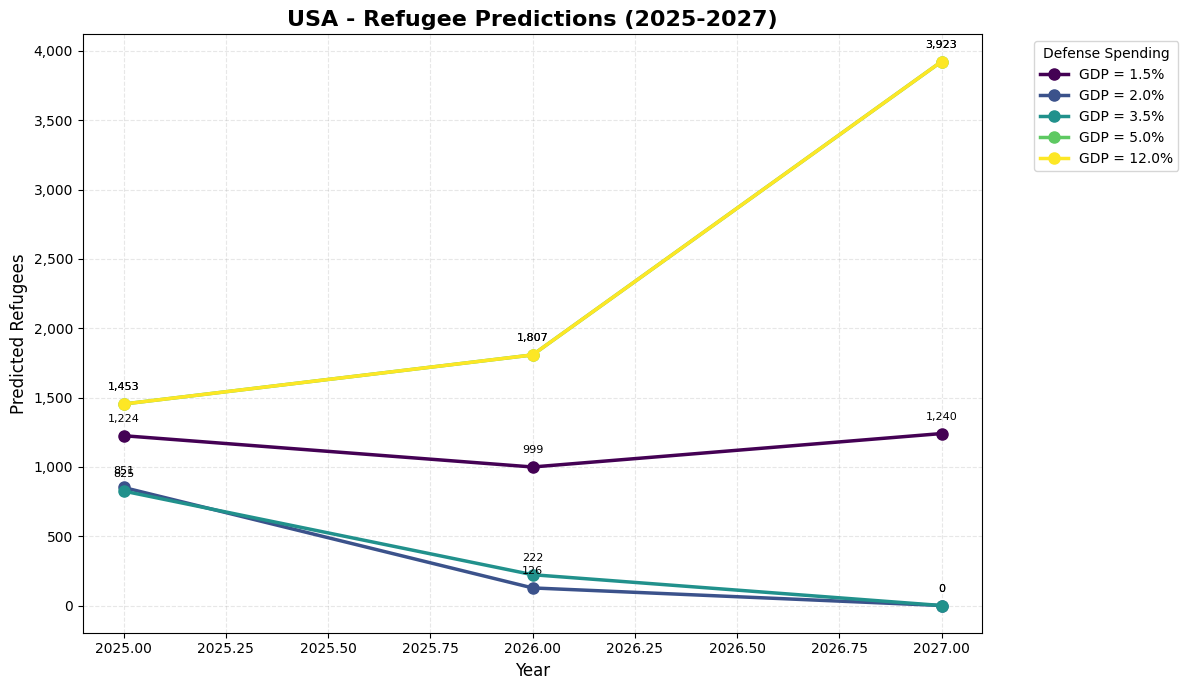

  Saved RUS_forecast.png


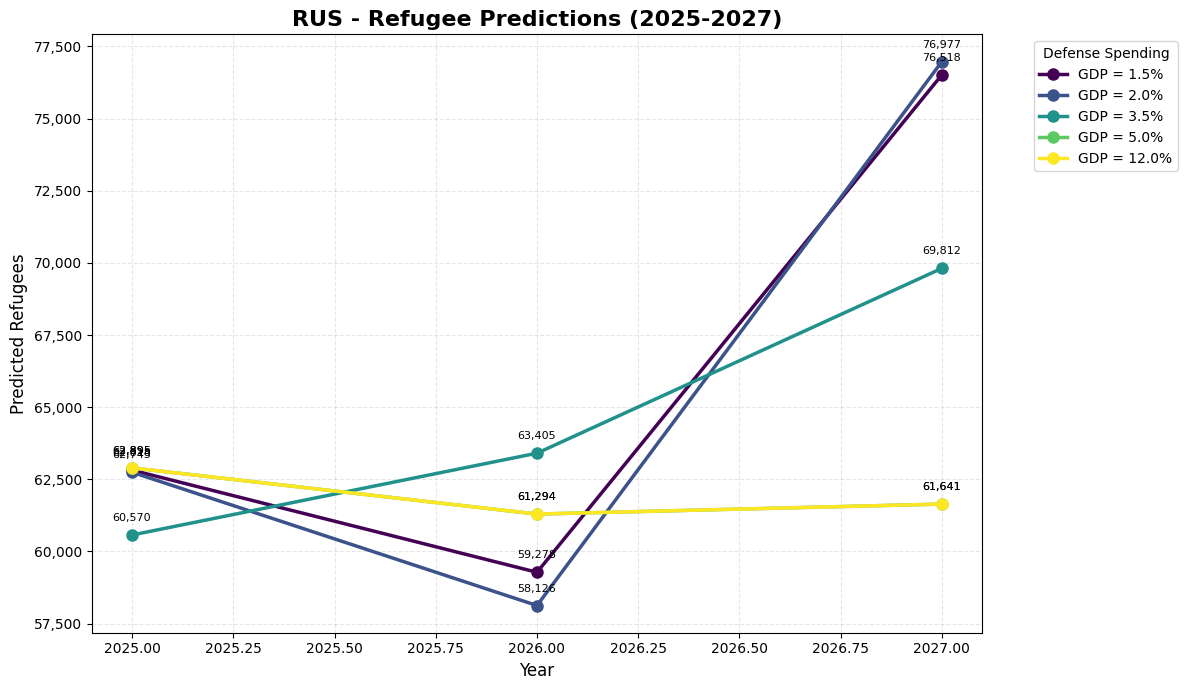

  Saved CHN_forecast.png


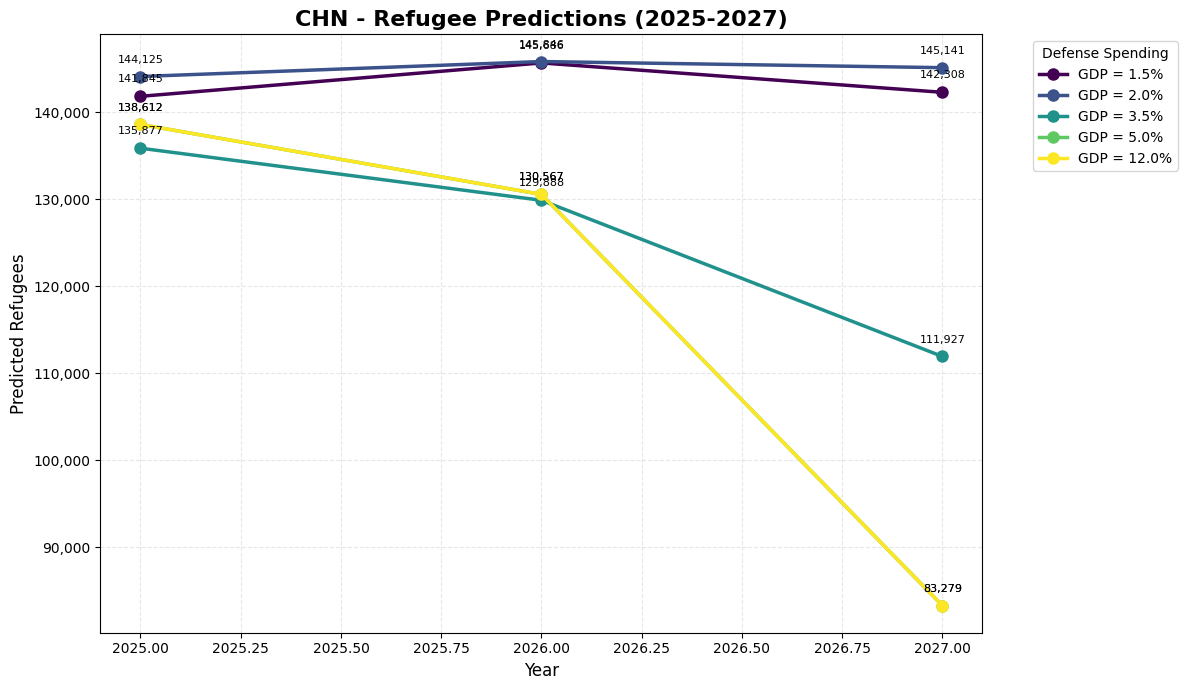

  Saved GBR_forecast.png


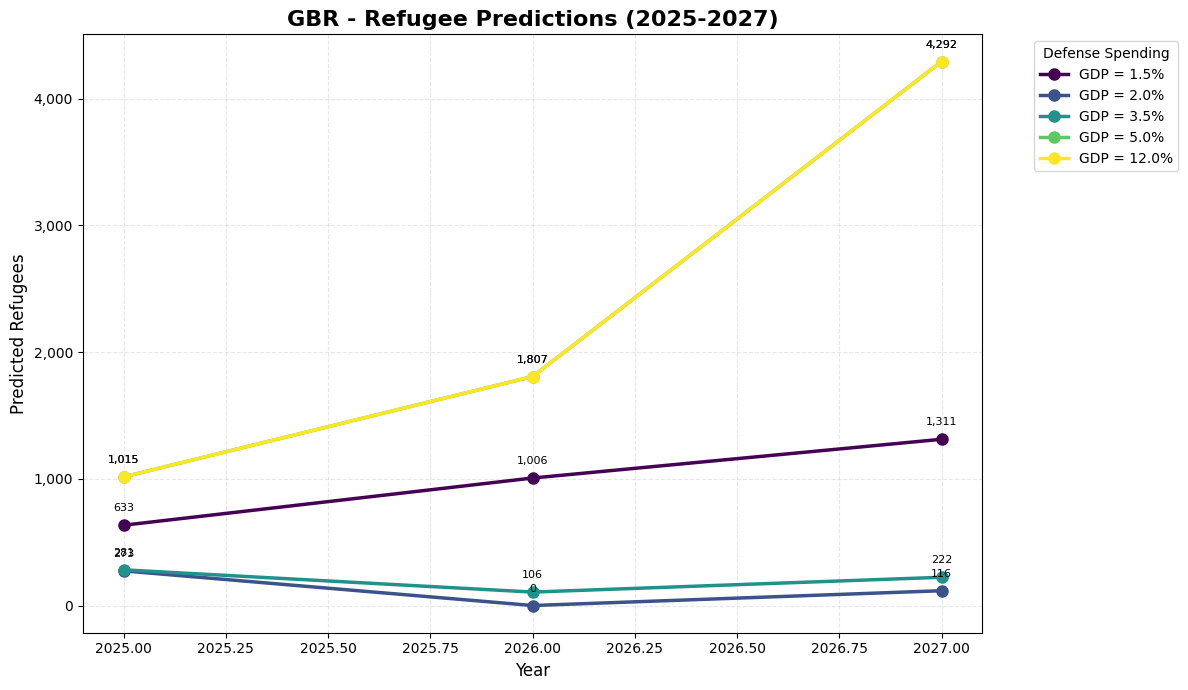

  Saved FRA_forecast.png


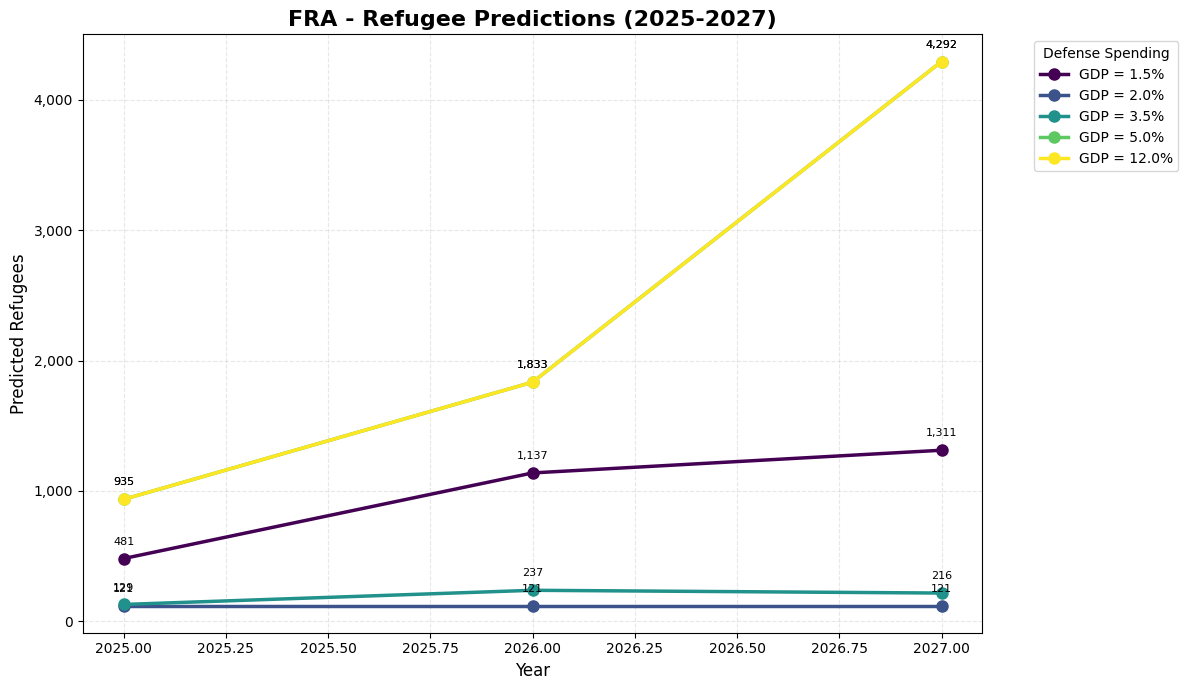


2️⃣ Creating subplot with all countries...
  Saved all_countries_subplots.png


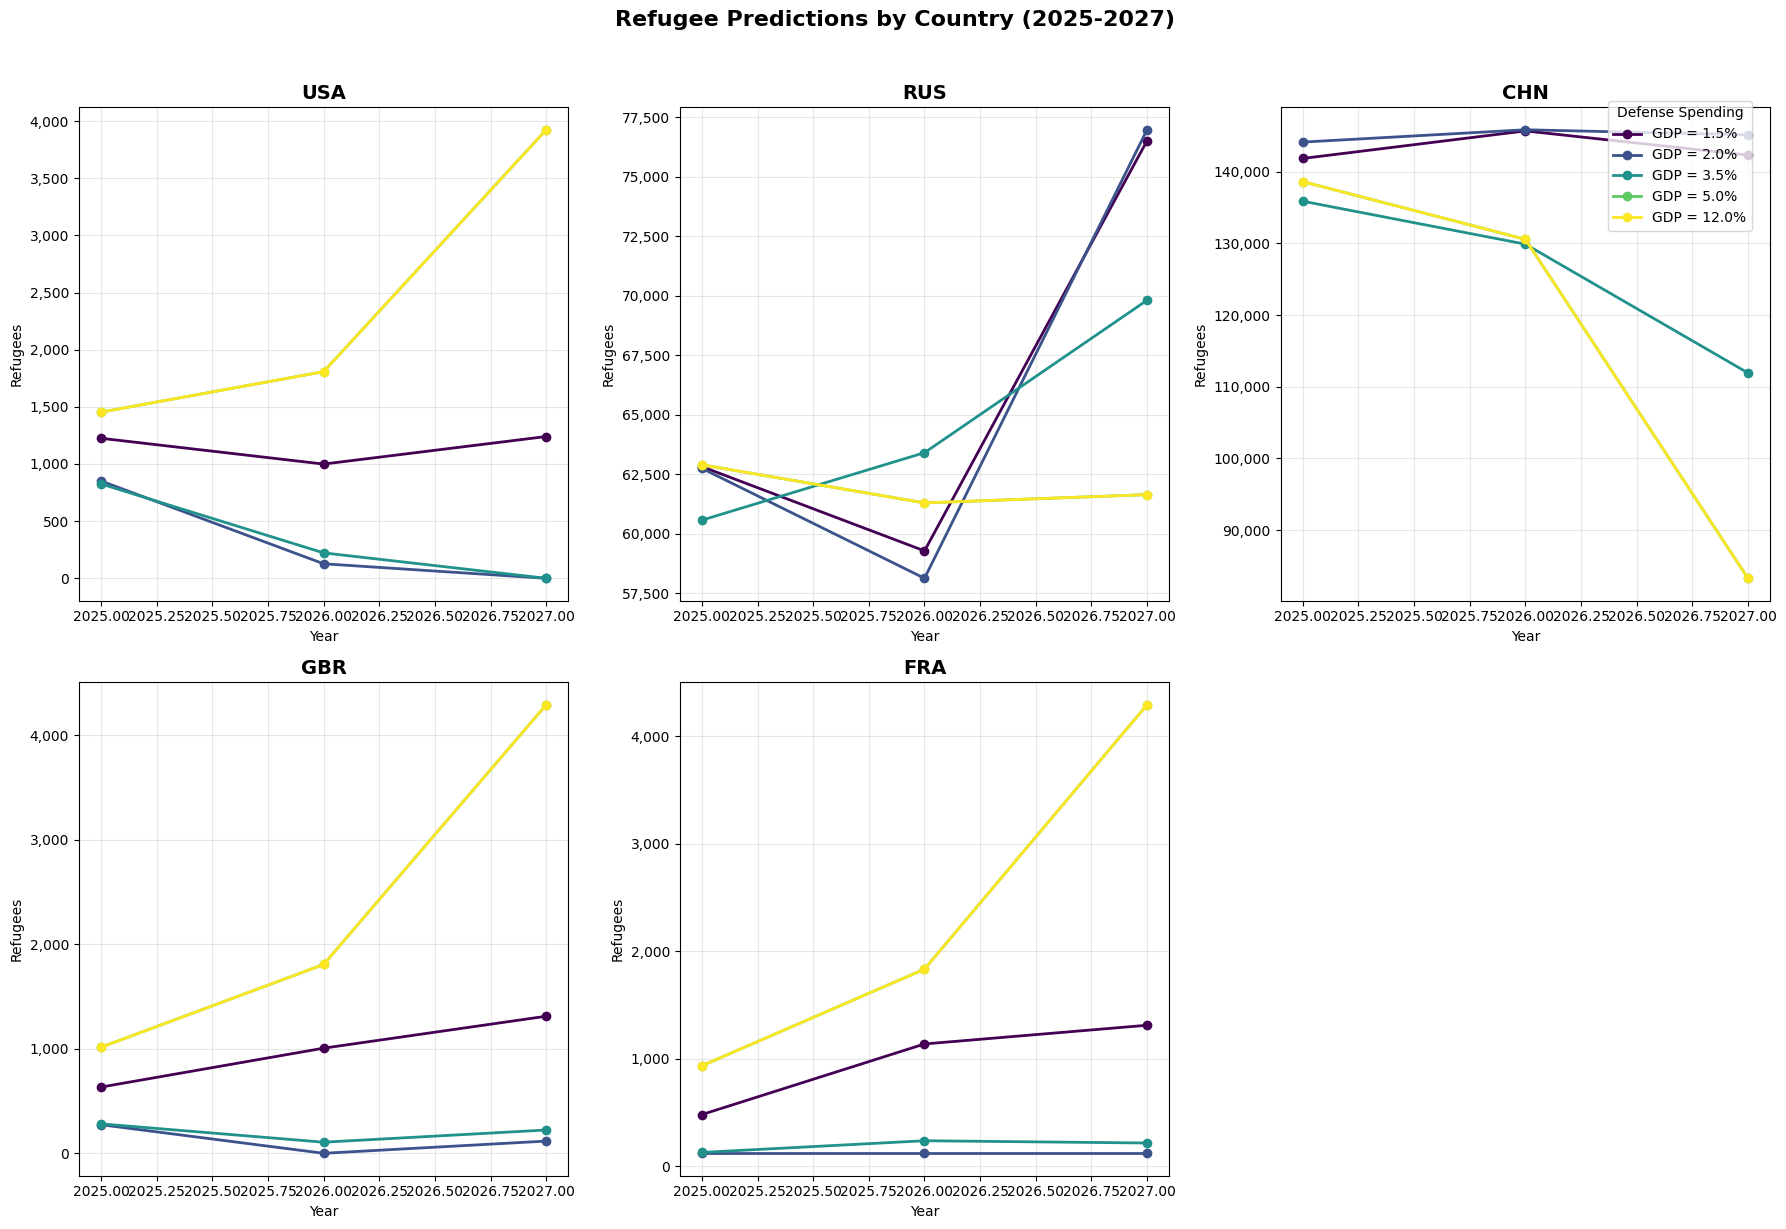


3️⃣ Creating GDP comparison bar charts...
  Saved USA_2027_comparison.png


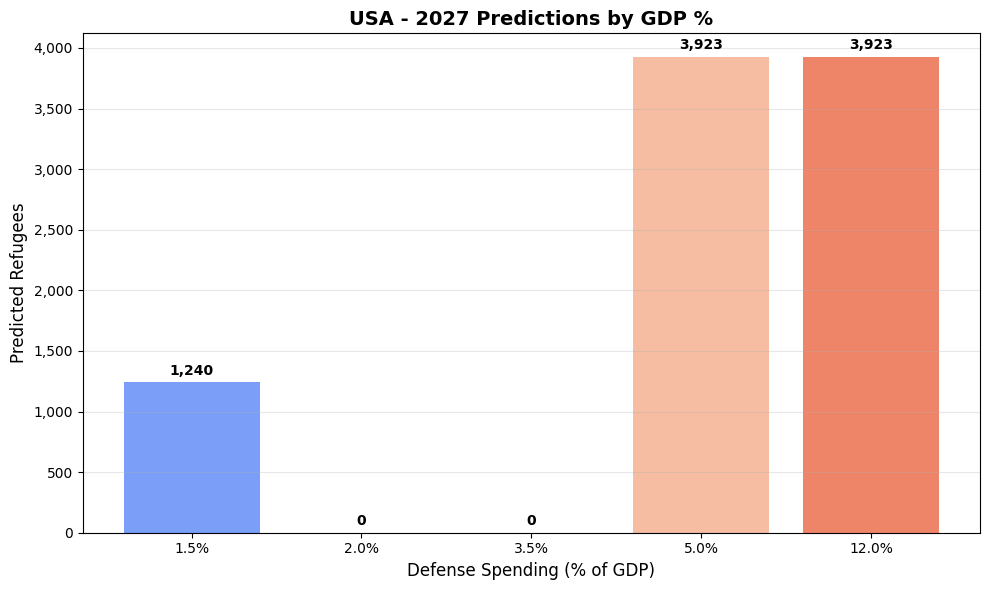

  Saved RUS_2027_comparison.png


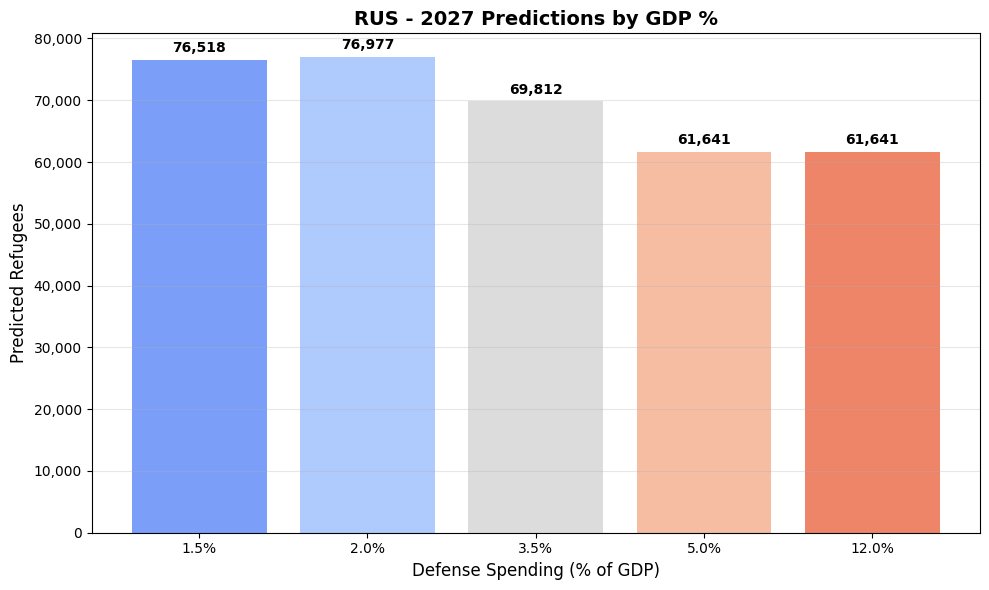

  Saved CHN_2027_comparison.png


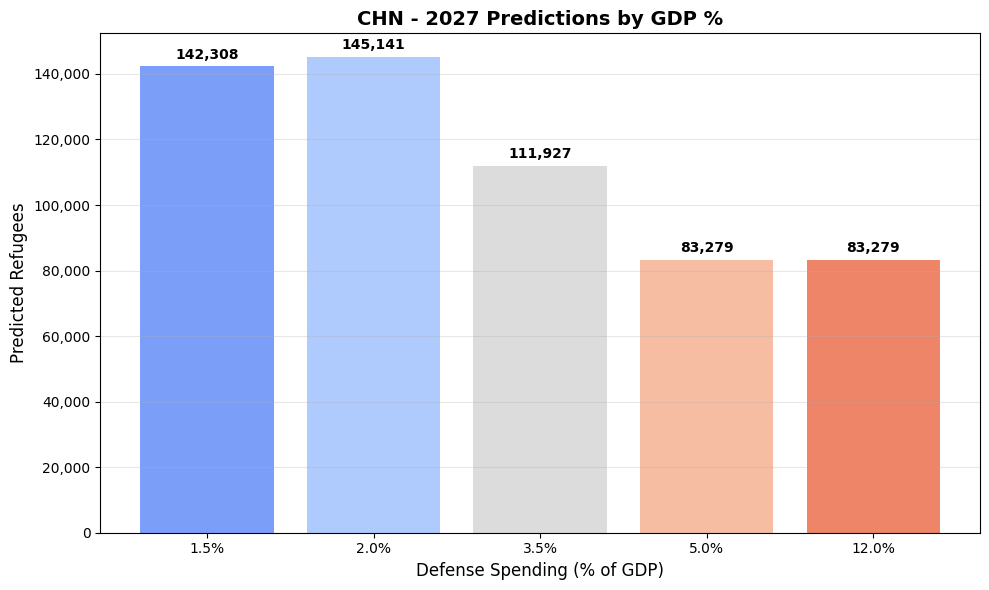

  Saved GBR_2027_comparison.png


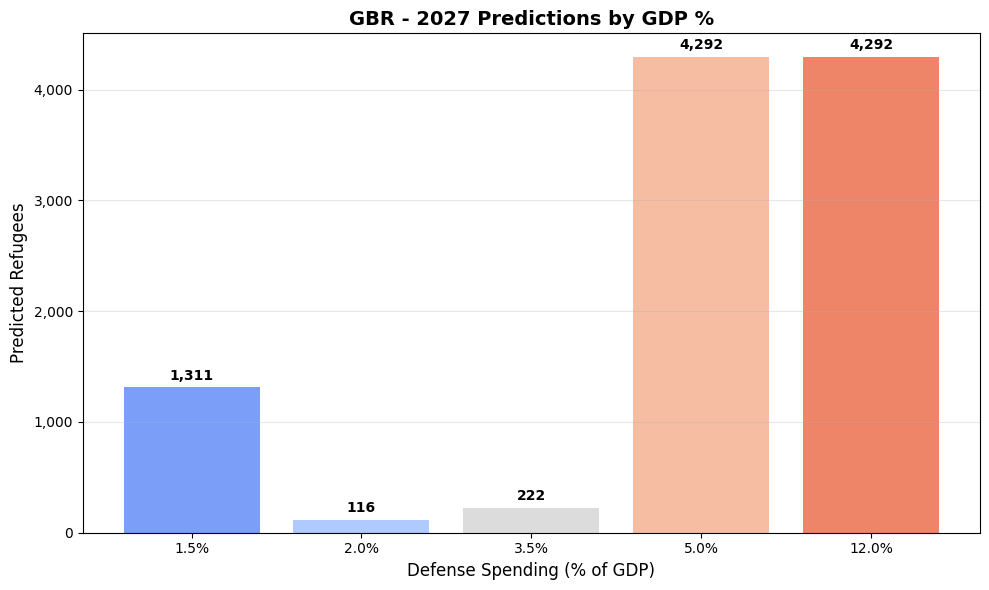

  Saved FRA_2027_comparison.png


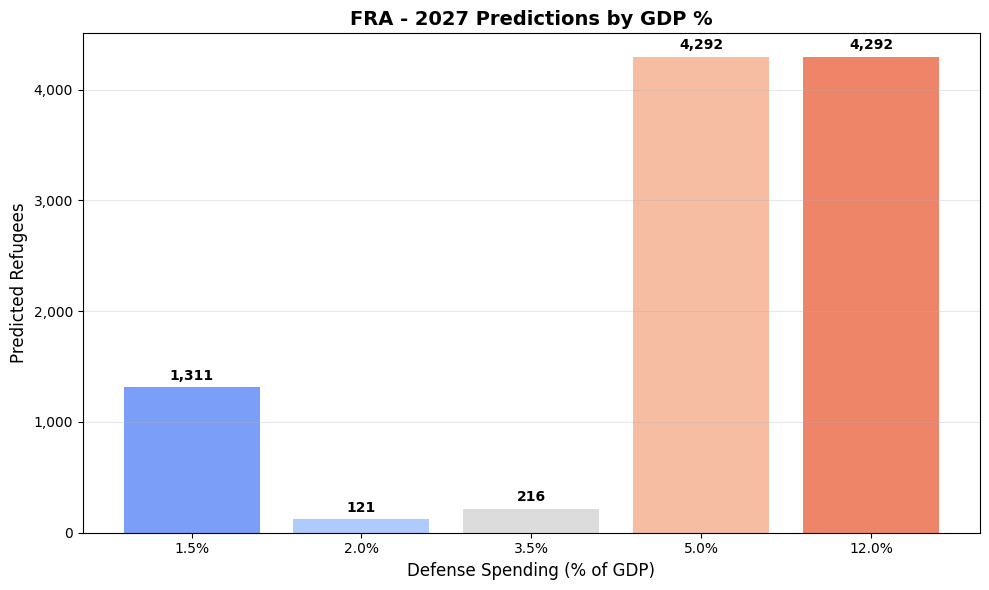


4️⃣ Creating heatmaps...
  Saved heatmap_2025.png


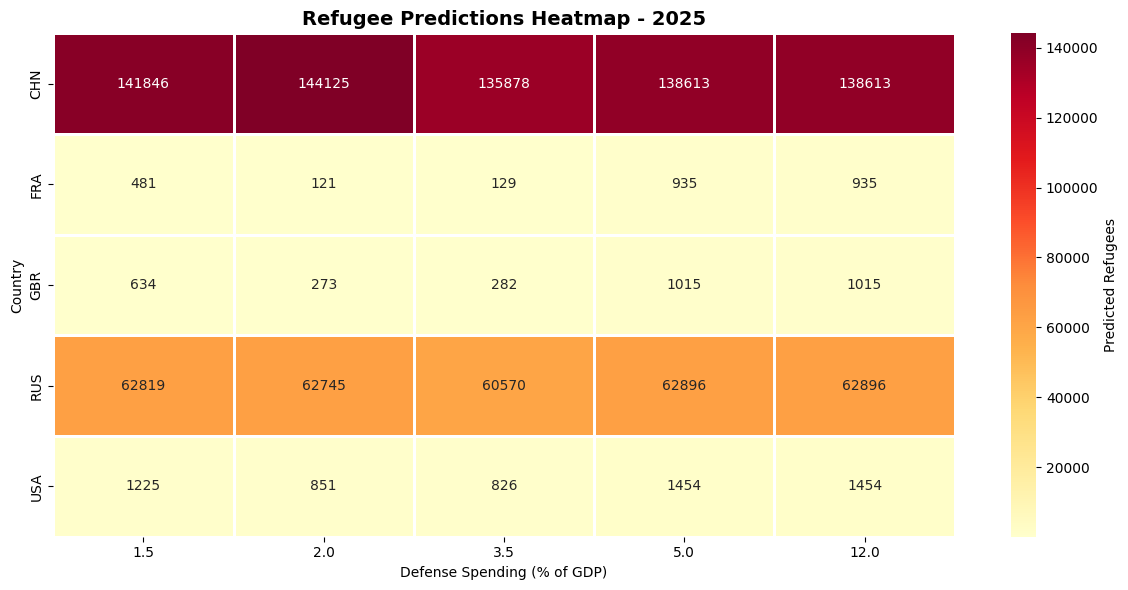

  Saved heatmap_2026.png


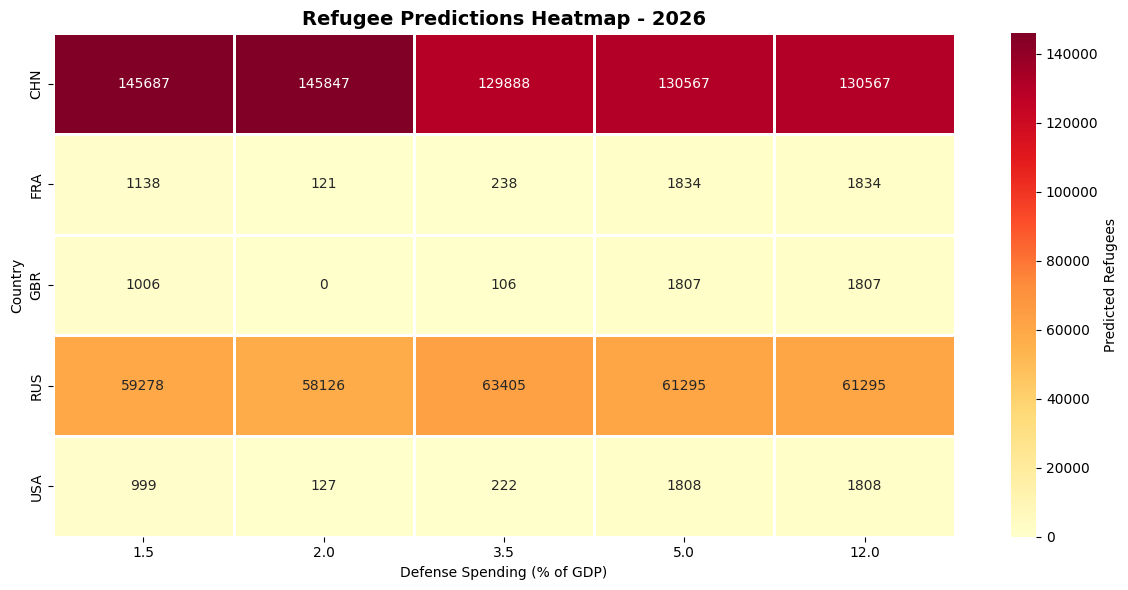

  Saved heatmap_2027.png


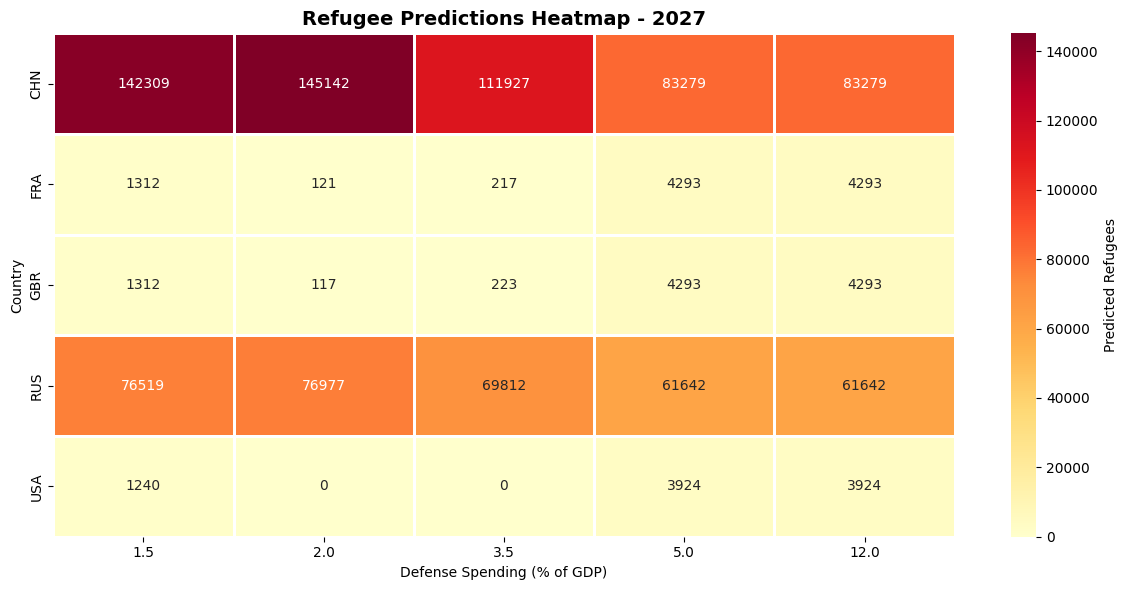


5️⃣ Creating line comparisons...
  Saved all_countries_gdp_1.5.png


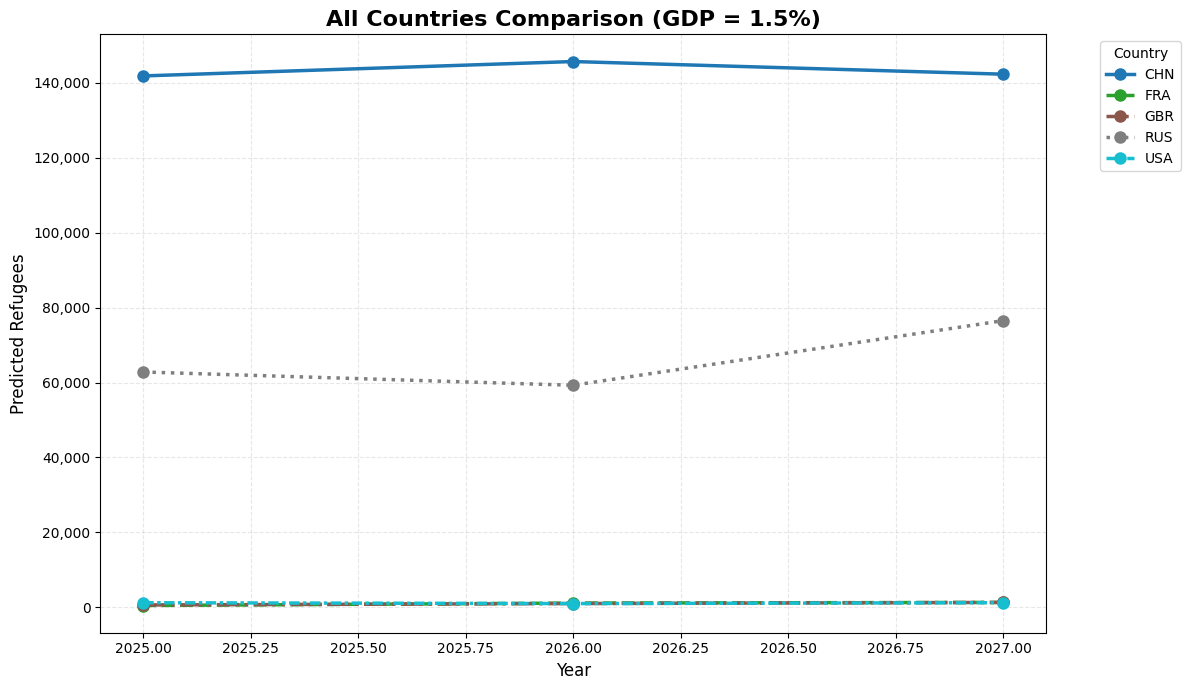

  Saved all_countries_gdp_2.0.png


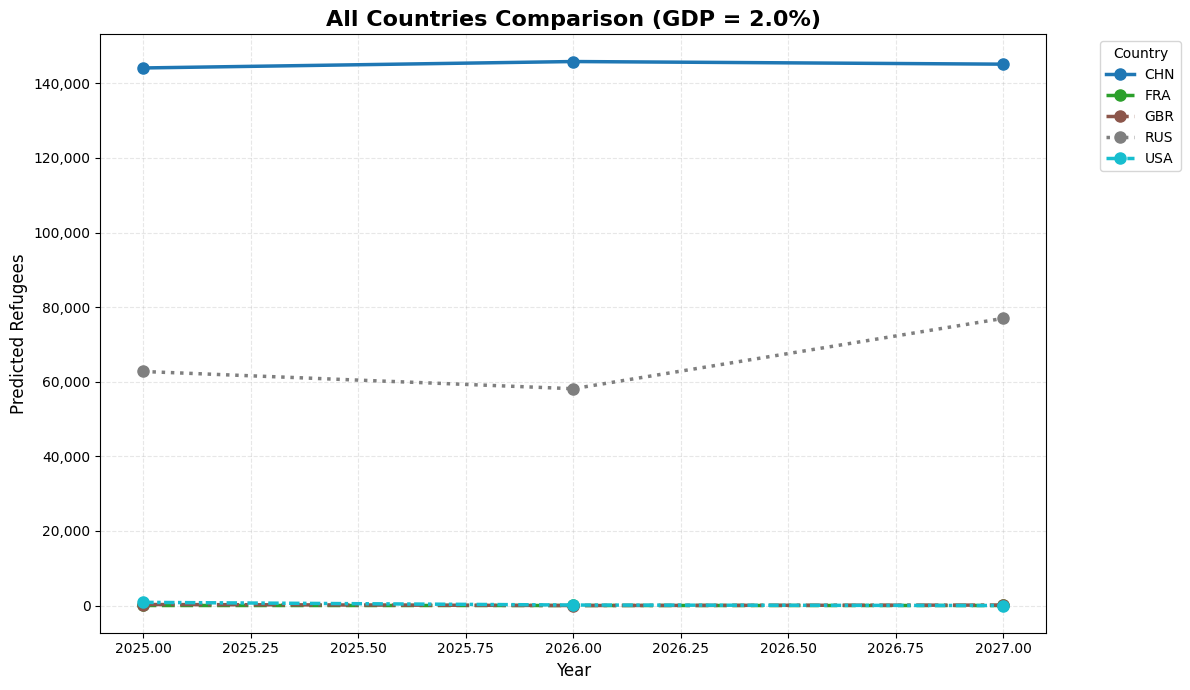

  Saved all_countries_gdp_3.5.png


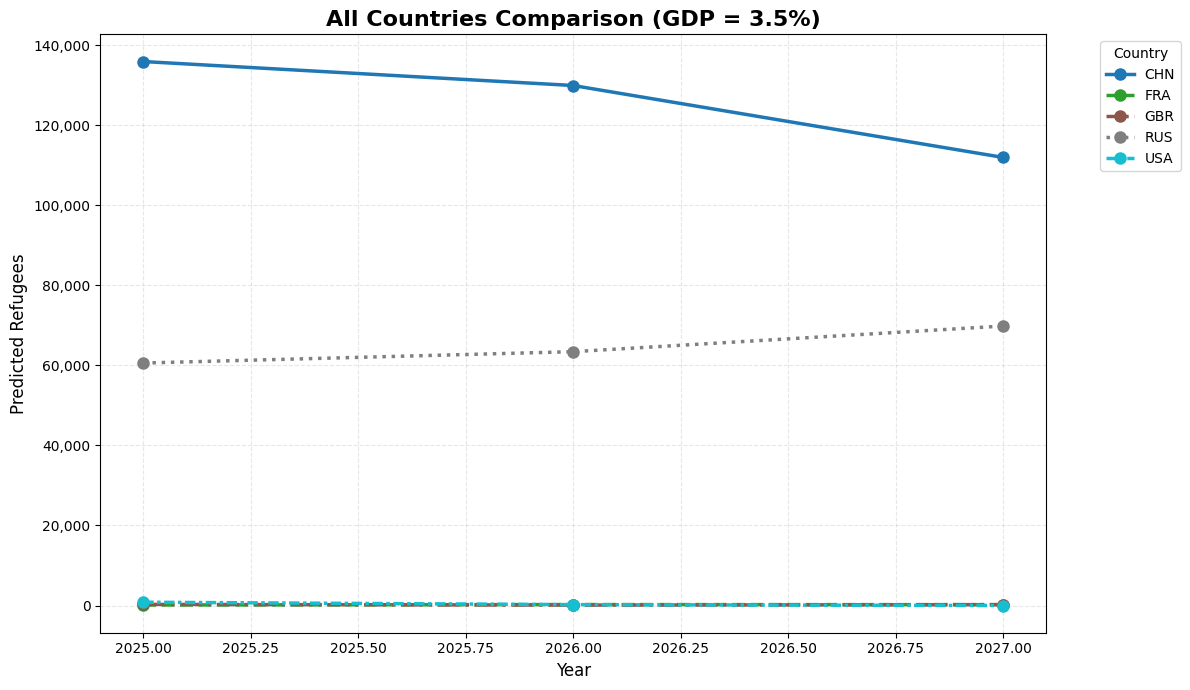

  Saved all_countries_gdp_5.0.png


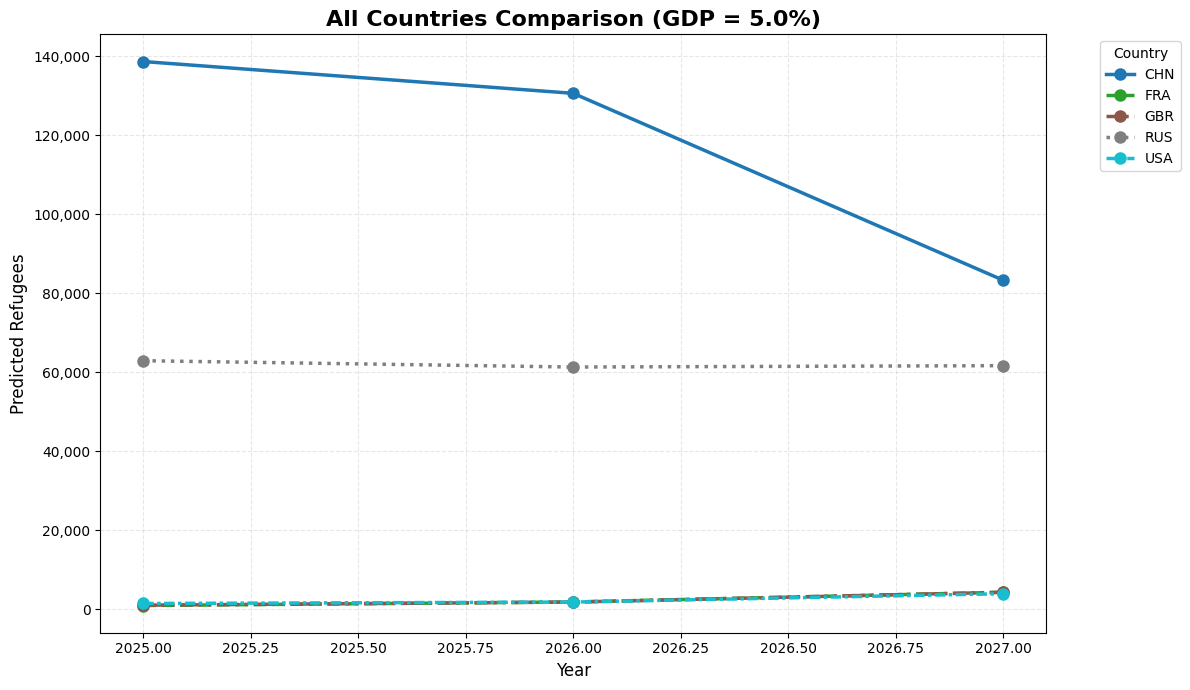

  Saved all_countries_gdp_12.0.png


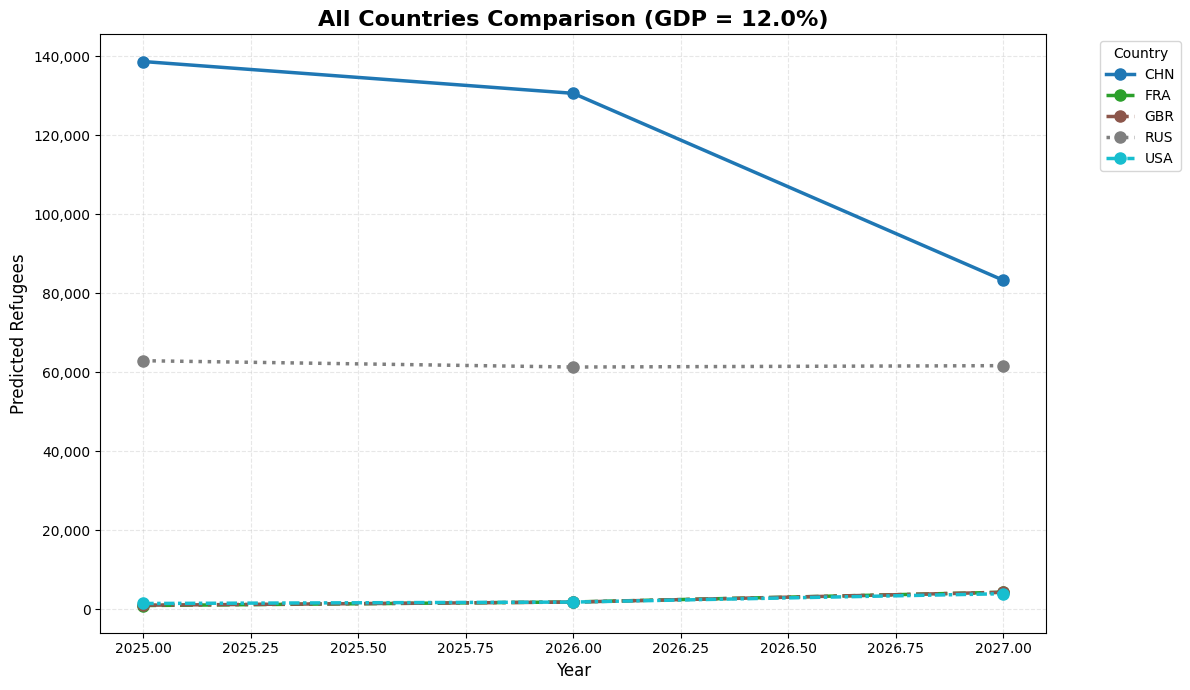


6️⃣ Creating trend analysis...
  Saved trend_analysis.png


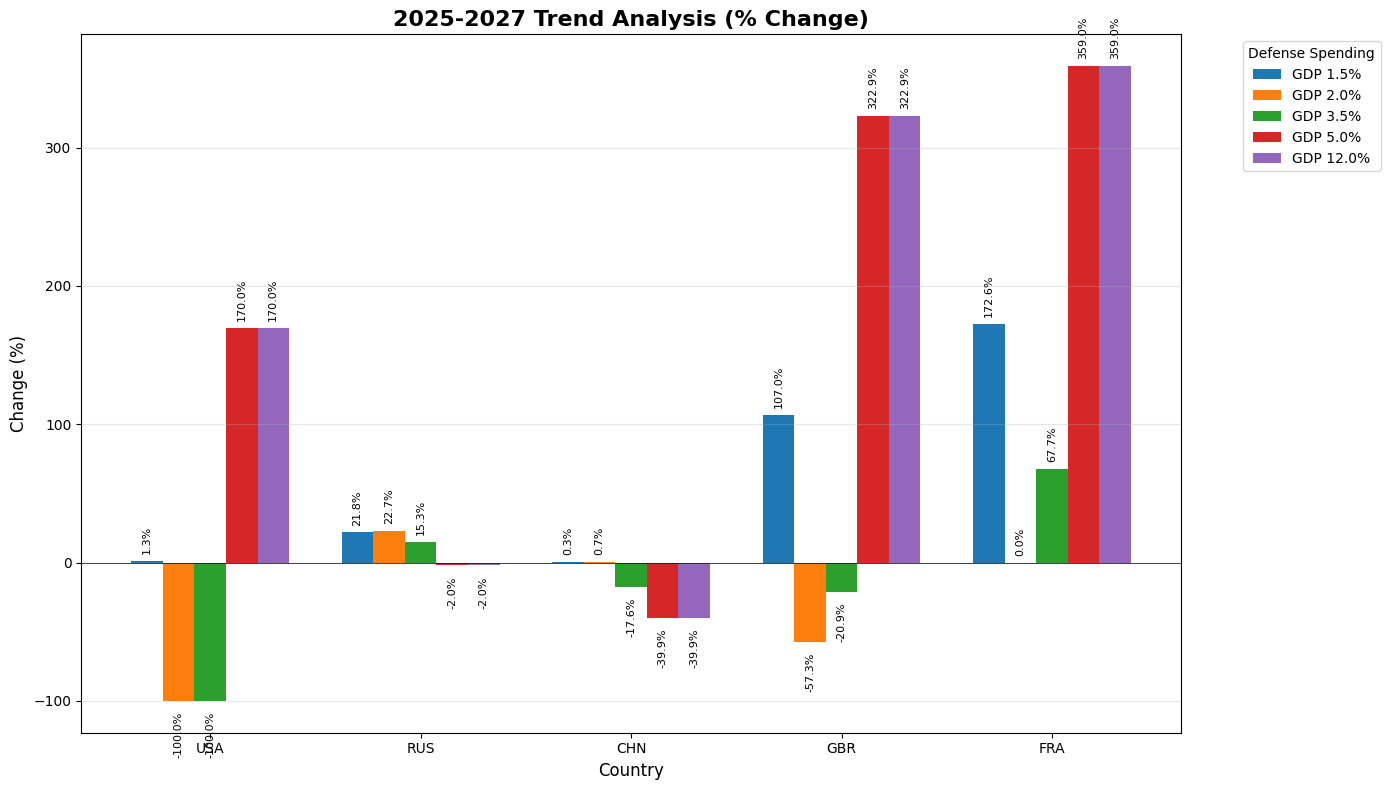


✅ All plots saved in folder: recursive_plots_20260314_141428


In [ ]:
# plot_recursive_forecasts.py
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import os

# =====================================================
# LOAD THE MODEL AND GENERATE FORECASTS
# =====================================================
def load_and_forecast(model_path="refugee_model.pkl"):
    """Load model and generate recursive forecasts"""

    # Load model
    print(f"Loading model from {model_path}...")
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
    print("✅ Model loaded successfully!")

    # Define GDP values
    GDP_VALUES = [1.5, 2.0, 3.5, 5.0, 12.0]
    countries = ['USA', 'RUS', 'CHN', 'GBR', 'FRA']

    # Generate forecasts
    print("\n🔄 Generating recursive forecasts...")
    all_forecasts = []

    for country in countries:
        for gdp in GDP_VALUES:
            try:
                forecast = model_data['recursive_forecast'](
                    model_data=model_data,
                    country=country,
                    start_year=2025,
                    defense_gdp=gdp,
                    years_to_predict=3
                )

                forecast['Country'] = country
                forecast['GDP_%'] = gdp
                all_forecasts.append(forecast)
                print(f"  ✓ {country} - GDP {gdp}%")
            except Exception as e:
                print(f"  ⚠️ Error: {e}")

    return pd.concat(all_forecasts, ignore_index=True)

# =====================================================
# PLOTTING FUNCTIONS
# =====================================================

def plot_country_all_gdp(df, country, save=False):
    """Plot one country with all GDP scenarios"""
    plt.figure(figsize=(12, 7))

    country_data = df[df['Country'] == country]
    gdp_values = sorted(country_data['GDP_%'].unique())

    # Use a nice color palette
    colors = plt.cm.viridis(np.linspace(0, 1, len(gdp_values)))

    # Plot each GDP scenario
    for i, gdp in enumerate(gdp_values):
        gdp_data = country_data[country_data['GDP_%'] == gdp].sort_values('Year')
        plt.plot(gdp_data['Year'], gdp_data['Predicted_Refugees'],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[i], label=f'GDP = {gdp}%')

    # Customize the plot
    plt.title(f'{country} - Refugee Predictions (2025-2027)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Predicted Refugees', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(title='Defense Spending', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Format y-axis with commas
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Add value labels on points
    for i, gdp in enumerate(gdp_values):
        gdp_data = country_data[country_data['GDP_%'] == gdp].sort_values('Year')
        for _, row in gdp_data.iterrows():
            plt.annotate(f'{int(row["Predicted_Refugees"]):,}',
                        (row['Year'], row['Predicted_Refugees']),
                        textcoords="offset points", xytext=(0,10),
                        ha='center', fontsize=8)

    plt.tight_layout()

    if save:
        plt.savefig(f'{country}_forecast.png', dpi=300, bbox_inches='tight')
        print(f"  Saved {country}_forecast.png")

    plt.show()


def plot_all_countries_subplot(df, save=False):
    """Create subplots for all countries"""
    countries = ['USA', 'RUS', 'CHN', 'GBR', 'FRA']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    gdp_values = sorted(df['GDP_%'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(gdp_values)))

    for idx, country in enumerate(countries):
        ax = axes[idx]
        country_data = df[df['Country'] == country]

        for i, gdp in enumerate(gdp_values):
            gdp_data = country_data[country_data['GDP_%'] == gdp].sort_values('Year')
            ax.plot(gdp_data['Year'], gdp_data['Predicted_Refugees'],
                   marker='o', linewidth=2, markersize=6,
                   color=colors[i], label=f'{gdp}%' if idx == 0 else "")

        ax.set_title(country, fontsize=14, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Refugees')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Remove empty subplot
    for idx in range(len(countries), len(axes)):
        fig.delaxes(axes[idx])

    # Add legend
    fig.legend([f'GDP = {gdp}%' for gdp in gdp_values],
               loc='upper right', bbox_to_anchor=(0.98, 0.95),
               title='Defense Spending', fontsize=10)

    plt.suptitle('Refugee Predictions by Country (2025-2027)',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save:
        plt.savefig('all_countries_subplots.png', dpi=300, bbox_inches='tight')
        print("  Saved all_countries_subplots.png")

    plt.show()


def plot_gdp_comparison_bar(df, country, year=2027, save=False):
    """Bar chart comparing GDP scenarios for a specific year"""
    plt.figure(figsize=(10, 6))

    year_data = df[(df['Country'] == country) & (df['Year'] == year)].sort_values('GDP_%')

    gdp_values = year_data['GDP_%'].values
    predictions = year_data['Predicted_Refugees'].values

    # Create bars with color gradient
    bars = plt.bar(range(len(gdp_values)), predictions,
                   color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(gdp_values))))

    # Add value labels
    for bar, pred in zip(bars, predictions):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(predictions)*0.01,
                f'{int(pred):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xlabel('Defense Spending (% of GDP)', fontsize=12)
    plt.ylabel('Predicted Refugees', fontsize=12)
    plt.title(f'{country} - {year} Predictions by GDP %', fontsize=14, fontweight='bold')
    plt.xticks(range(len(gdp_values)), [f'{gdp}%' for gdp in gdp_values])
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    if save:
        plt.savefig(f'{country}_{year}_comparison.png', dpi=300, bbox_inches='tight')
        print(f"  Saved {country}_{year}_comparison.png")

    plt.show()


def plot_heatmap(df, year=2027, save=False):
    """Heatmap of predictions for all countries and GDP values"""
    plt.figure(figsize=(12, 6))

    year_data = df[df['Year'] == year]
    heatmap_data = year_data.pivot_table(
        values='Predicted_Refugees',
        index='Country',
        columns='GDP_%',
        aggfunc='first'
    )

    # Create heatmap
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=1, cbar_kws={'label': 'Predicted Refugees'})

    plt.title(f'Refugee Predictions Heatmap - {year}', fontsize=14, fontweight='bold')
    plt.xlabel('Defense Spending (% of GDP)')
    plt.ylabel('Country')

    plt.tight_layout()

    if save:
        plt.savefig(f'heatmap_{year}.png', dpi=300, bbox_inches='tight')
        print(f"  Saved heatmap_{year}.png")

    plt.show()


def plot_line_comparison(df, gdp=1.5, save=False):
    """Compare all countries for a specific GDP value"""
    plt.figure(figsize=(12, 7))

    gdp_data = df[df['GDP_%'] == gdp]
    countries = sorted(gdp_data['Country'].unique())

    # Use different line styles for each country
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
    colors = plt.cm.tab10(np.linspace(0, 1, len(countries)))

    for i, country in enumerate(countries):
        country_data = gdp_data[gdp_data['Country'] == country].sort_values('Year')
        plt.plot(country_data['Year'], country_data['Predicted_Refugees'],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[i], linestyle=line_styles[i % len(line_styles)],
                label=country)

    plt.title(f'All Countries Comparison (GDP = {gdp}%)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Predicted Refugees', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.tight_layout()

    if save:
        plt.savefig(f'all_countries_gdp_{gdp}.png', dpi=300, bbox_inches='tight')
        print(f"  Saved all_countries_gdp_{gdp}.png")

    plt.show()


def plot_trend_analysis(df, save=False):
    """Plot trend analysis showing % change"""
    plt.figure(figsize=(14, 8))

    countries = ['USA', 'RUS', 'CHN', 'GBR', 'FRA']
    gdp_values = sorted(df['GDP_%'].unique())

    x = np.arange(len(countries))
    width = 0.15
    multiplier = 0

    for gdp in gdp_values:
        changes = []
        for country in countries:
            country_data = df[(df['Country'] == country) & (df['GDP_%'] == gdp)].sort_values('Year')
            if len(country_data) >= 2:
                first = country_data.iloc[0]['Predicted_Refugees']
                last = country_data.iloc[-1]['Predicted_Refugees']
                change = ((last - first) / first) * 100
                changes.append(change)
            else:
                changes.append(0)

        offset = width * multiplier
        bars = plt.bar(x + offset, changes, width, label=f'GDP {gdp}%')
        multiplier += 1

    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Change (%)', fontsize=12)
    plt.title('2025-2027 Trend Analysis (% Change)', fontsize=16, fontweight='bold')
    plt.xticks(x + width * 2, countries)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend(title='Defense Spending', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add value labels
    for i, gdp in enumerate(gdp_values):
        for j, country in enumerate(countries):
            country_data = df[(df['Country'] == country) & (df['GDP_%'] == gdp)].sort_values('Year')
            if len(country_data) >= 2:
                first = country_data.iloc[0]['Predicted_Refugees']
                last = country_data.iloc[-1]['Predicted_Refugees']
                change = ((last - first) / first) * 100
                plt.text(j + i*width, change + (5 if change >= 0 else -8),
                        f'{change:.1f}%', ha='center', va='bottom' if change >= 0 else 'top',
                        fontsize=8, rotation=90)

    plt.tight_layout()

    if save:
        plt.savefig('trend_analysis.png', dpi=300, bbox_inches='tight')
        print("  Saved trend_analysis.png")

    plt.show()

# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":

    # Either load existing CSV or generate new forecasts
    csv_file = 'recursive_forecast_2025_2027.csv'

    if os.path.exists(csv_file):
        print(f"Loading existing forecasts from {csv_file}...")
        df = pd.read_csv(csv_file)
        print("✅ Data loaded from CSV")
    else:
        print("No existing CSV found. Generating new forecasts...")
        df = load_and_forecast("refugee_model.pkl")
        df.to_csv('recursive_forecast_2025_2027.csv', index=False)
        print("✅ Forecasts saved to CSV")

    print("\n" + "="*80)
    print("📊 GENERATING PLOTS")
    print("="*80)

    # Create a directory for plots
    plot_dir = f'recursive_plots_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
    os.makedirs(plot_dir, exist_ok=True)
    os.chdir(plot_dir)

    # Generate all plots
    print("\n1️⃣ Creating individual country plots...")
    for country in ['USA', 'RUS', 'CHN', 'GBR', 'FRA']:
        plot_country_all_gdp(df, country, save=True)

    print("\n2️⃣ Creating subplot with all countries...")
    plot_all_countries_subplot(df, save=True)

    print("\n3️⃣ Creating GDP comparison bar charts...")
    for country in ['USA', 'RUS', 'CHN', 'GBR', 'FRA']:
        plot_gdp_comparison_bar(df, country, year=2027, save=True)

    print("\n4️⃣ Creating heatmaps...")
    for year in [2025, 2026, 2027]:
        plot_heatmap(df, year=year, save=True)

    print("\n5️⃣ Creating line comparisons...")
    for gdp in [1.5, 2.0, 3.5, 5.0, 12.0]:
        plot_line_comparison(df, gdp=gdp, save=True)

    print("\n6️⃣ Creating trend analysis...")
    plot_trend_analysis(df, save=True)

    print(f"\n✅ All plots saved in folder: {plot_dir}")
    print("="*80)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import h5py
import pickle
import joblib
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"Dataset loaded: {df.shape}")
    return df

def prepare_refugee_features(df, target_col='Refugees'):
    """
    Prepare features specifically for refugee prediction
    """
    df_processed = df.copy()

    print("\nPREPARING FEATURES FOR REFUGEE PREDICTION...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # Store country mapping
    country_mapping = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
    print(f"   Country mapping: {country_mapping}")

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Refugees',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Conflict_Intensity'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP', 'Refugees', 'Asylum Seekers']:
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )
            df_processed[f'{var}_Rolling_Std_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).std()
            ).fillna(0)

    # 6. Create interaction features
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
            df_processed['Conflict_Squared'] = df_processed['Conflict_Intensity'] ** 2
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Create refugee-to-population ratio
    if 'Refugees' in df_processed.columns and 'Population' in df_processed.columns:
        df_processed['Refugees_per_Capita'] = df_processed['Refugees'] / df_processed['Population']
        df_processed['Refugees_per_Capita_Lag_1'] = df_processed.groupby('Country')['Refugees_per_Capita'].shift(1)

    # 8. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

# ==========================
# RECURSIVE FORECASTING FUNCTIONS
# ==========================
def recursive_forecast(model, country, start_year, defense_gdp, conflict_intensity,
                       years_to_predict, historical_data, feature_names, scaler, le_country):
    """
    Generate recursive forecasts for multiple years with proper lag updates
    """
    print(f"\n{'='*60}")
    print(f"RECURSIVE FORECASTING FOR {country} - {years_to_predict} YEARS")
    print(f"{'='*60}")

    # Get historical data for this country
    country_history = historical_data[historical_data['Country'] == country].copy()
    country_history = country_history.sort_values('Year')

    if len(country_history) < 3:
        print(f"Error: Insufficient historical data for {country}")
        return None

    print(f"\nHistorical data: {len(country_history)} years ({country_history['Year'].min()} to {country_history['Year'].max()})")

    # Create working dataframe that will be updated with predictions
    working_df = country_history.copy()

    predictions = []
    actual_values = []
    performance_metrics = []

    current_year = start_year
    current_defense = defense_gdp
    current_conflict = conflict_intensity

    for year_idx in range(years_to_predict):
        print(f"\n--- Predicting Year {current_year} (Iteration {year_idx+1}/{years_to_predict}) ---")

        # Create feature dictionary with updated lag values from working_df
        feature_dict = create_feature_dict(
            working_df, country, current_year, current_defense, current_conflict,
            le_country, historical_data['Year'].min()
        )

        # Create DataFrame with correct feature order
        feature_df = pd.DataFrame([feature_dict])[feature_names]

        # Check if we have actual value for this year (for performance tracking)
        actual_value = None
        if current_year in country_history['Year'].values:
            actual_value = country_history[country_history['Year'] == current_year]['Refugees'].values[0]
            actual_values.append({'Year': current_year, 'Actual': actual_value})
            print(f"  Actual value available: {actual_value:,.0f}")

        # Scale and predict
        feature_scaled = scaler.transform(feature_df)
        prediction = model.predict(feature_scaled)[0]
        prediction = max(0, prediction)  # Ensure non-negative

        # Store prediction
        pred_entry = {
            'Year': current_year,
            'Predicted': prediction,
            'Defense_GDP': current_defense,
            'Conflict_Intensity': current_conflict
        }

        if actual_value is not None:
            pred_entry['Actual'] = actual_value
            error = abs(prediction - actual_value)
            pct_error = (error / actual_value * 100) if actual_value > 0 else np.nan
            pred_entry['Absolute_Error'] = error
            pred_entry['Percent_Error'] = pct_error
            print(f"  Prediction: {prediction:,.0f} (Error: {error:,.0f}, {pct_error:.1f}%)")
        else:
            print(f"  Prediction: {prediction:,.0f}")

        predictions.append(pred_entry)

        # Update working dataframe with predicted value for next iteration
        new_row = working_df.iloc[-1].copy()
        new_row['Year'] = current_year
        new_row['Refugees'] = prediction
        new_row['D_Expenditure_GDP'] = current_defense
        new_row['Conflict_Intensity'] = current_conflict

        # Update derived features
        if 'Refugees_per_Capita' in working_df.columns:
            new_row['Refugees_per_Capita'] = prediction / new_row['Population'] if new_row['Population'] > 0 else 0

        if 'Defense_Conflict_Interaction' in working_df.columns:
            new_row['Defense_Conflict_Interaction'] = current_defense * current_conflict

        # Append to working dataframe
        working_df = pd.concat([working_df, pd.DataFrame([new_row])], ignore_index=True)

        # Update lag features in working_df (they'll be used in next iteration)
        update_lag_features(working_df)

        current_year += 1

        # Optional: Adjust defense and conflict for next year (can be modified based on scenarios)
        # current_defense = current_defense * 1.02  # Example: 2% increase each year

    # Calculate performance metrics if we have actual values
    if actual_values:
        performance_metrics = calculate_recursive_metrics(predictions)

    return pd.DataFrame(predictions), performance_metrics

def create_feature_dict(working_df, country, year, defense_gdp, conflict_intensity,
                        le_country, min_year):
    """
    Create feature dictionary with properly updated lag values
    """
    # Get the latest data (last row is most recent)
    latest = working_df.iloc[-1].copy()

    feature_dict = {
        'Year': year,
        'Year_Scaled': year - min_year,
        'Country_Encoded': le_country.transform([country])[0],
        'D_Expenditure_GDP': defense_gdp,
    }

    # Defense lag features (using working_df which includes predictions)
    defense_values = working_df['D_Expenditure_GDP'].tail(3).tolist()
    while len(defense_values) < 3:
        defense_values.insert(0, defense_gdp)

    feature_dict['D_Expenditure_GDP_Lag_1'] = defense_values[-2] if len(defense_values) >= 2 else defense_gdp
    feature_dict['D_Expenditure_GDP_Lag_2'] = defense_values[-3] if len(defense_values) >= 3 else defense_gdp
    feature_dict['D_Expenditure_GDP_Rolling_Mean_3'] = np.mean(defense_values)
    feature_dict['D_Expenditure_GDP_Rolling_Std_3'] = np.std(defense_values) if len(defense_values) >= 2 else 0
    feature_dict['Defense_Squared'] = defense_gdp ** 2

    # Refugee lag features (critical for recursive forecasting)
    refugee_values = working_df['Refugees'].tail(4).tolist()  # Get last 4 for lags 1-3
    while len(refugee_values) < 4:
        refugee_values.insert(0, refugee_values[0] if refugee_values else 0)

    feature_dict['Refugees_Lag_1'] = refugee_values[-2] if len(refugee_values) >= 2 else 0
    feature_dict['Refugees_Lag_2'] = refugee_values[-3] if len(refugee_values) >= 3 else 0
    feature_dict['Refugees_Lag_3'] = refugee_values[-4] if len(refugee_values) >= 4 else 0
    feature_dict['Refugees_Rolling_Mean_3'] = np.mean(refugee_values[-3:]) if len(refugee_values) >= 3 else 0
    feature_dict['Refugees_Rolling_Std_3'] = np.std(refugee_values[-3:]) if len(refugee_values) >= 3 else 0

    # Conflict features
    conflict_values = working_df['Conflict_Intensity'].tail(3).tolist()
    while len(conflict_values) < 3:
        conflict_values.insert(0, conflict_intensity)

    feature_dict['Conflict_Intensity'] = conflict_intensity
    feature_dict['Conflict_Intensity_Lag_1'] = conflict_values[-2] if len(conflict_values) >= 2 else conflict_intensity
    feature_dict['Conflict_Intensity_Lag_2'] = conflict_values[-3] if len(conflict_values) >= 3 else conflict_intensity
    feature_dict['Conflict_Squared'] = conflict_intensity ** 2

    # Asylum features
    if 'Asylum Seekers' in working_df.columns:
        asylum_values = working_df['Asylum Seekers'].tail(3).tolist()
        while len(asylum_values) < 3:
            asylum_values.insert(0, asylum_values[0] if asylum_values else 0)

        feature_dict['Asylum Seekers'] = asylum_values[-1]
        feature_dict['Asylum Seekers_Lag_1'] = asylum_values[-2] if len(asylum_values) >= 2 else 0
        feature_dict['Asylum Seekers_Lag_2'] = asylum_values[-3] if len(asylum_values) >= 3 else 0
        feature_dict['Asylum Seekers_Rolling_Mean_3'] = np.mean(asylum_values)

    # Population features
    if 'Population' in working_df.columns:
        pop_values = working_df['Population'].tail(2).tolist()
        feature_dict['Population'] = pop_values[-1]
        feature_dict['Population_Lag_1'] = pop_values[-2] if len(pop_values) >= 2 else pop_values[-1]

    # Economic features (use latest from working_df)
    for feat in ['GDP_Current_USDollars', 'GDP_Growth_Annual', 'Inflation_Annual', 'Unemployment_Total_of_TLF']:
        if feat in working_df.columns:
            feature_dict[feat] = working_df[feat].iloc[-1]

    # Derived features
    if 'Refugees_per_Capita' in working_df.columns:
        feature_dict['Refugees_per_Capita'] = working_df['Refugees_per_Capita'].iloc[-1]
        feature_dict['Refugees_per_Capita_Lag_1'] = working_df['Refugees_per_Capita'].iloc[-2] if len(working_df) >= 2 else 0

    if 'Defense_Conflict_Interaction' in working_df.columns:
        feature_dict['Defense_Conflict_Interaction'] = defense_gdp * conflict_intensity

    return feature_dict

def update_lag_features(df):
    """
    Update lag features in dataframe after adding new predictions
    """
    # Recalculate all lag features
    for var in ['D_Expenditure_GDP', 'Refugees', 'Asylum Seekers', 'Conflict_Intensity',
                'Population', 'Refugees_per_Capita']:
        if var in df.columns:
            for lag in [1, 2, 3]:
                lag_col = f'{var}_Lag_{lag}'
                if lag_col in df.columns:
                    df[lag_col] = df[var].shift(lag)

    # Update rolling statistics
    for var in ['D_Expenditure_GDP', 'Refugees', 'Asylum Seekers']:
        if var in df.columns:
            roll_mean_col = f'{var}_Rolling_Mean_3'
            roll_std_col = f'{var}_Rolling_Std_3'
            if roll_mean_col in df.columns:
                df[roll_mean_col] = df[var].rolling(window=3, min_periods=1).mean()
            if roll_std_col in df.columns:
                df[roll_std_col] = df[var].rolling(window=3, min_periods=1).std().fillna(0)

def calculate_recursive_metrics(predictions):
    """
    Calculate performance metrics for recursive forecasts
    """
    pred_df = pd.DataFrame(predictions)
    pred_df = pred_df[pred_df['Actual'].notna()]

    if len(pred_df) == 0:
        return {}

    metrics = {
        'MAE': mean_absolute_error(pred_df['Actual'], pred_df['Predicted']),
        'RMSE': np.sqrt(mean_squared_error(pred_df['Actual'], pred_df['Predicted'])),
        'R2': r2_score(pred_df['Actual'], pred_df['Predicted']),
        'MAPE': np.mean(np.abs((pred_df['Actual'] - pred_df['Predicted']) / pred_df['Actual'])) * 100,
        'Max_Error': np.max(np.abs(pred_df['Actual'] - pred_df['Predicted'])),
        'Min_Error': np.min(np.abs(pred_df['Actual'] - pred_df['Predicted']))
    }

    # Year-by-year metrics
    yearly_metrics = []
    for year in sorted(pred_df['Year'].unique()):
        year_data = pred_df[pred_df['Year'] == year]
        if len(year_data) > 0:
            yearly_metrics.append({
                'Year': year,
                'MAE': mean_absolute_error(year_data['Actual'], year_data['Predicted']),
                'MAPE': np.mean(np.abs((year_data['Actual'] - year_data['Predicted']) / year_data['Actual'])) * 100
            })

    print(f"\n{'='*60}")
    print("RECURSIVE FORECAST PERFORMANCE METRICS")
    print(f"{'='*60}")
    print(f"MAE:  {metrics['MAE']:,.2f}")
    print(f"RMSE: {metrics['RMSE']:,.2f}")
    print(f"R²:   {metrics['R2']:.4f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"Max Error: {metrics['Max_Error']:,.2f}")
    print(f"Min Error: {metrics['Min_Error']:,.2f}")

    print(f"\nYear-by-Year Performance:")
    for ym in yearly_metrics:
        print(f"  {ym['Year']}: MAE={ym['MAE']:,.0f}, MAPE={ym['MAPE']:.1f}%")

    return {'overall': metrics, 'yearly': yearly_metrics}

# ==========================
# REFUGEE PREDICTION MODEL
# ==========================
class RefugeePredictor:
    """
    XGBoost model for refugee prediction with recursive forecasting
    """
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.best_r2 = None
        self.mae = None
        self.rmse = None
        self.training_date = None
        self.historical_data = None
        self.country_stats = {}
        self.recursive_metrics = {}

    def get_refugee_features(self, df):
        """
        Get all available features for refugee prediction
        """
        base_features = ['Year_Scaled', 'Country_Encoded']

        defense_features = ['D_Expenditure_GDP', 'D_Expenditure_GDP_Lag_1',
                           'D_Expenditure_GDP_Lag_2', 'D_Expenditure_GDP_Rolling_Mean_3',
                           'D_Expenditure_GDP_Rolling_Std_3', 'Defense_Squared']

        refugee_features = ['Refugees_Lag_1', 'Refugees_Lag_2', 'Refugees_Lag_3',
                           'Refugees_Rolling_Mean_3', 'Refugees_Rolling_Std_3']

        conflict_features = ['Conflict_Intensity', 'Conflict_Intensity_Lag_1',
                            'Conflict_Intensity_Lag_2', 'Conflict_Squared']

        economic_features = ['GDP_Current_USDollars', 'GDP_Growth_Annual',
                            'Inflation_Annual', 'Unemployment_Total_of_TLF']

        asylum_features = ['Asylum Seekers', 'Asylum Seekers_Lag_1',
                          'Asylum Seekers_Lag_2', 'Asylum Seekers_Rolling_Mean_3']

        population_features = ['Population', 'Population_Lag_1']

        derived_features = ['Refugees_per_Capita', 'Refugees_per_Capita_Lag_1',
                           'Defense_Conflict_Interaction']

        # Combine all features and filter existing
        all_features = (base_features + defense_features + refugee_features +
                       conflict_features + economic_features + asylum_features +
                       population_features + derived_features)

        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\nREFUGEE MODEL FEATURES ({len(available_features)} total)")
        for i, f in enumerate(available_features[:10]):
            print(f"  {i+1}. {f}")
        if len(available_features) > 10:
            print(f"  ... and {len(available_features)-10} more")

        return available_features

    def train(self, df, target_col='Refugees', test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model for refugee prediction
        """
        print("\n" + "="*60)
        print("TRAINING REFUGEE PREDICTION MODEL")
        print("="*60)

        # Store historical data
        self.historical_data = df.copy()

        # Get features
        self.feature_names = self.get_refugee_features(df)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\nData Split: {len(X_train)} training, {len(X_test)} testing")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\nTraining XGBoost...")
        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Create native booster for saving
        self.booster = self.model.get_booster()
        self.training_date = datetime.now()

        # Store country statistics
        for country in df['Country'].unique():
            country_data = df[df['Country'] == country].sort_values('Year')
            self.country_stats[country] = {
                'last_year': country_data['Year'].iloc[-1],
                'historical_data': country_data.tail(10).to_dict('records')
            }

        # Evaluate
        self.evaluate(X_test_scaled, y_test)

        # Test recursive forecasting on validation period
        self.test_recursive_forecasting(df, test_years[:3])  # Test on first 3 test years

        return self.model

    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        y_pred = self.model.predict(X_test)

        # Overall metrics
        self.best_r2 = r2_score(y_test, y_pred)
        self.mae = mean_absolute_error(y_test, y_pred)
        self.rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"\nOverall Performance:")
        print(f"  R² Score:  {self.best_r2:.4f} ({self.best_r2*100:.1f}% accuracy)")
        print(f"  MAE:       {self.mae:,.2f} refugees")
        print(f"  RMSE:      {self.rmse:,.2f} refugees")

    def test_recursive_forecasting(self, df, test_years):
        """
        Test recursive forecasting on historical data to get performance metrics
        """
        print("\n" + "="*60)
        print("TESTING RECURSIVE FORECASTING ON VALIDATION PERIOD")
        print("="*60)

        all_predictions = []

        for country in df['Country'].unique()[:3]:  # Test on first 3 countries
            # Get historical data before test years
            historical = df[(df['Country'] == country) & (~df['Year'].isin(test_years))]

            if len(historical) < 3:
                continue

            # Get actual defense and conflict for first test year
            first_test_year = test_years[0]
            test_data = df[(df['Country'] == country) & (df['Year'].isin(test_years))]

            if len(test_data) == 0:
                continue

            defense_val = test_data['D_Expenditure_GDP'].iloc[0]
            conflict_val = test_data['Conflict_Intensity'].iloc[0] if 'Conflict_Intensity' in test_data.columns else 0

            # Create temporary working dataframe
            working_df = pd.concat([historical, test_data.iloc[:1]])  # Add first test year as starting point

            # Run recursive forecast
            predictions, metrics = recursive_forecast(
                model=self.model,
                country=country,
                start_year=test_years[0] + 1,  # Start from second test year
                defense_gdp=defense_val,
                conflict_intensity=conflict_val,
                years_to_predict=len(test_years) - 1,
                historical_data=working_df,
                feature_names=self.feature_names,
                scaler=self.scaler,
                le_country=self.le_country
            )

            if predictions is not None:
                all_predictions.append(predictions)
                self.recursive_metrics[country] = metrics

        return all_predictions

    def recursive_forecast(self, country, start_year, defense_gdp, conflict_intensity,
                          years_to_predict=5):
        """
        Public method to run recursive forecasting
        """
        if self.model is None or self.historical_data is None:
            print("Model or historical data not loaded!")
            return None, None

        return recursive_forecast(
            model=self.model,
            country=country,
            start_year=start_year,
            defense_gdp=defense_gdp,
            conflict_intensity=conflict_intensity,
            years_to_predict=years_to_predict,
            historical_data=self.historical_data,
            feature_names=self.feature_names,
            scaler=self.scaler,
            le_country=self.le_country
        )

    # ==========================
    # SAVING FUNCTIONS
    # ==========================
    def save_to_h5(self, filename='refugee_model.h5'):
        """Save model to .h5 format"""
        print("\n" + "="*60)
        print("SAVING MODEL TO .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'w') as f:
            # Save model
            model_bytes = self.booster.save_raw()
            f.create_dataset('model_bytes', data=np.frombuffer(model_bytes, dtype='uint8'))

            # Save scaler
            f.create_dataset('scaler_mean', data=self.scaler.mean_)
            f.create_dataset('scaler_scale', data=self.scaler.scale_)

            # Save feature names
            dt = h5py.string_dtype(encoding='utf-8')
            f.create_dataset('feature_names',
                           data=np.array(self.feature_names, dtype=object).astype('S'),
                           dtype=dt)

            # Save country mapping
            if self.le_country:
                country_data = np.array(list(self.le_country.classes_), dtype=object).astype('S')
                f.create_dataset('countries', data=country_data, dtype=dt)
                f.create_dataset('country_codes', data=self.le_country.transform(self.le_country.classes_))

            # Save metadata
            f.attrs['r2_score'] = self.best_r2
            f.attrs['mae'] = self.mae
            f.attrs['rmse'] = self.rmse
            f.attrs['n_features'] = len(self.feature_names)
            f.attrs['created_date'] = str(self.training_date)
            f.attrs['model_type'] = 'XGBoost Refugee Predictor with Recursive Forecasting'

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename} ({file_size:.2f} KB)")
        return filename

    def save_to_pkl(self, filename='refugee_model.pkl'):
        """Save model to .pkl format"""
        print("\n" + "="*60)
        print("SAVING MODEL TO .pkl FORMAT")
        print("="*60)

        model_data = {
            'model': self.model,
            'booster': self.booster,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'historical_data': self.historical_data,
            'country_stats': self.country_stats,
            'recursive_metrics': self.recursive_metrics,
            'country_mapping': dict(zip(self.le_country.classes_, self.le_country.transform(self.le_country.classes_))) if self.le_country else None,
            'metrics': {
                'r2_score': self.best_r2,
                'mae': self.mae,
                'rmse': self.rmse
            },
            'training_date': self.training_date,
            'model_type': 'XGBoost Refugee Predictor with Recursive Forecasting'
        }

        with open(filename, 'wb') as f:
            pickle.dump(model_data, f)

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename} ({file_size:.2f} KB)")
        return filename

    def save_to_joblib(self, filename='refugee_model.joblib'):
        """Save model to .joblib format"""
        print("\n" + "="*60)
        print("SAVING MODEL TO .joblib FORMAT")
        print("="*60)

        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'historical_data': self.historical_data,
            'country_stats': self.country_stats,
            'recursive_metrics': self.recursive_metrics,
            'metrics': {
                'r2_score': self.best_r2,
                'mae': self.mae,
                'rmse': self.rmse
            },
            'training_date': self.training_date
        }

        joblib.dump(model_data, filename)

        file_size = os.path.getsize(filename) / 1024
        print(f"Model saved to: {filename} ({file_size:.2f} KB)")
        return filename

    def save_all_formats(self, base_filename='refugee_model'):
        """Save model in all formats"""
        print("\n" + "="*60)
        print("SAVING MODEL IN ALL FORMATS")
        print("="*60)

        saved_files = []
        saved_files.append(self.save_to_h5(f"{base_filename}.h5"))
        saved_files.append(self.save_to_pkl(f"{base_filename}.pkl"))
        saved_files.append(self.save_to_joblib(f"{base_filename}.joblib"))

        print(f"\nAll formats saved successfully!")
        return saved_files

    def load_from_pkl(self, filename):
        """Load model from .pkl format"""
        print("\n" + "="*60)
        print("LOADING MODEL FROM .pkl FORMAT")
        print("="=60)

        with open(filename, 'rb') as f:
            model_data = pickle.load(f)

        self.model = model_data['model']
        self.booster = model_data.get('booster', None)
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.le_country = model_data['le_country']
        self.historical_data = model_data.get('historical_data', None)
        self.country_stats = model_data.get('country_stats', {})
        self.recursive_metrics = model_data.get('recursive_metrics', {})
        self.best_r2 = model_data['metrics']['r2_score']
        self.mae = model_data['metrics']['mae']
        self.rmse = model_data['metrics']['rmse']
        self.training_date = model_data['training_date']

        print(f"\nModel Info:")
        print(f"  Type: {model_data.get('model_type', 'XGBoost')}")
        print(f"  R² Score: {self.best_r2:.4f}")
        print(f"  MAE: {self.mae:,.2f}")
        print(f"  Training Date: {self.training_date}")
        print(f"  Recursive Metrics Available: {len(self.recursive_metrics) > 0}")

        return self

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("REFUGEE PREDICTION MODEL WITH RECURSIVE FORECASTING")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_refugee_features(df)

    # Create and train model
    model = RefugeePredictor()
    model.le_country = le_country
    model.train(df_processed, target_col='Refugees')

    # Save in all formats
    saved_files = model.save_all_formats('refugee_model_recursive')

    # Demonstrate recursive forecasting
    print("\n" + "="*60)
    print("DEMONSTRATING RECURSIVE FORECASTING")
    print("="=60)

    test_countries = ['FRA', 'GBR', 'RUS']
    for country in test_countries:
        if country in df_processed['Country'].values:
            # Get latest defense and conflict values
            latest = df_processed[df_processed['Country'] == country].iloc[-1]
            defense_val = latest['D_Expenditure_GDP']
            conflict_val = latest['Conflict_Intensity'] if 'Conflict_Intensity' in latest else 2.0

            # Run recursive forecast
            predictions, metrics = model.recursive_forecast(
                country=country,
                start_year=2025,
                defense_gdp=defense_val,
                conflict_intensity=conflict_val,
                years_to_predict=5
            )

            if predictions is not None:
                print(f"\n{country} 5-Year Forecast:")
                print(predictions[['Year', 'Predicted', 'Defense_GDP']].to_string(index=False))

    # Show file locations
    print("\n" + "="=60)
    print("FILE LOCATIONS")
    print("="=60)
    print(f"Current directory: {os.getcwd()}")

    for file in saved_files:
        if os.path.exists(file):
            print(f"\n{file}:")
            print(f"  Path: {os.path.abspath(file)}")
            print(f"  Size: {os.path.getsize(file) / 1024:.2f} KB")

    # Optional: Download files in Colab
    try:
        from google.colab import files
        print("\nDownloading files to your computer...")
        for file in saved_files:
            files.download(file)
    except:
        pass

    return model, saved_files

if __name__ == "__main__":
    model, saved_files = main()

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (3013202610.py, line 709)